In [35]:
import pandas as pd

In [36]:
bike_data_raw = pd.read_csv('daily-bike-share.csv')

In [37]:
bike_data_raw

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,12/27/2012,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247
727,728,12/28/2012,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644
728,729,12/29/2012,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159
729,730,12/30/2012,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364


rentals będzie naszym y, pozostałe cechy są potencjalnym X. Jak można zauważyć, część przygotowania danych (feature engineering) została już wykonana. W danych mamy datę, jak i zmienne, które zostały już stworzone na podstawie daty, czyli informacja o miesiącu, czy jest święto, dzień tygodnia itd. Te nowe cechy stworzono właśnie w oparciu o Feature Engineering (inżynieria cech), zatem zrobił to ktoś za nas, z daty wyciągnął informację.

# Eksploracyjna Analiza Danych (EDA - Exploratory Data Analysis)


Zanim jednak zaczniemy uczyć modele, to zgodnie z CRISP-DM najpierw musimy je zrozumieć, a później będziemy mogli je przetworzyć.

Skorzystajmy z metody info i sprawdźmy typ zmiennych.

In [105]:
bike_data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  rentals     731 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(9)
memory usage: 80.1 KB


In [39]:
bike_data_raw['dteday'] = pd.to_datetime(bike_data_raw['dteday'])
display(bike_data_raw)
print(bike_data_raw.info())

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  rentals     731 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(9)
memory usage: 80.1 KB
None



Zobaczmy, jaki jest rozkład dla zmiennej objaśnianej rentals, która jest historyczną liczbą wypożyczonych rowerów.

In [40]:
bike_data_raw['rentals'].describe()

count     731.000000
mean      848.176471
std       686.622488
min         2.000000
25%       315.500000
50%       713.000000
75%      1096.000000
max      3410.000000
Name: rentals, dtype: float64

Liczba wypożyczonych rowerów wahała się pomiędzy 2 a 3410, zatem różnica jest spora. Spójrz na różnicę pomiędzy średnią a medianą (percentyl 50%). Średnia jest zdecydowanie większa, przez to rozkład zapewne nie będzie normalny, jak i również będzie skośny. 75% dni to liczba wypożyczonych rowerów mniejsza niż 1100, zatem wartość mniejsza o ponad 60% od liczby maksymalnej. Podczas zajęć z wizualizacji mogliśmy się przekonać, że dobry obraz jest wart więcej niż 1000 słów. Stwórzmy histogram oraz szacowany rozkład gęstości.

array([[<Axes: title={'center': 'instant'}>,
        <Axes: title={'center': 'dteday'}>,
        <Axes: title={'center': 'season'}>,
        <Axes: title={'center': 'yr'}>],
       [<Axes: title={'center': 'mnth'}>,
        <Axes: title={'center': 'holiday'}>,
        <Axes: title={'center': 'weekday'}>,
        <Axes: title={'center': 'workingday'}>],
       [<Axes: title={'center': 'weathersit'}>,
        <Axes: title={'center': 'temp'}>,
        <Axes: title={'center': 'atemp'}>,
        <Axes: title={'center': 'hum'}>],
       [<Axes: title={'center': 'windspeed'}>,
        <Axes: title={'center': 'rentals'}>, <Axes: >, <Axes: >]],
      dtype=object)

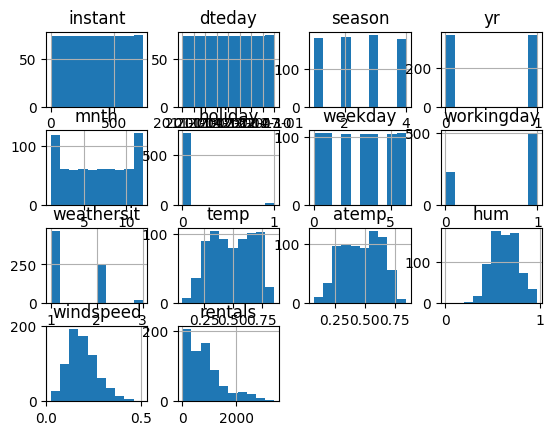

In [41]:
bike_data_raw.hist()

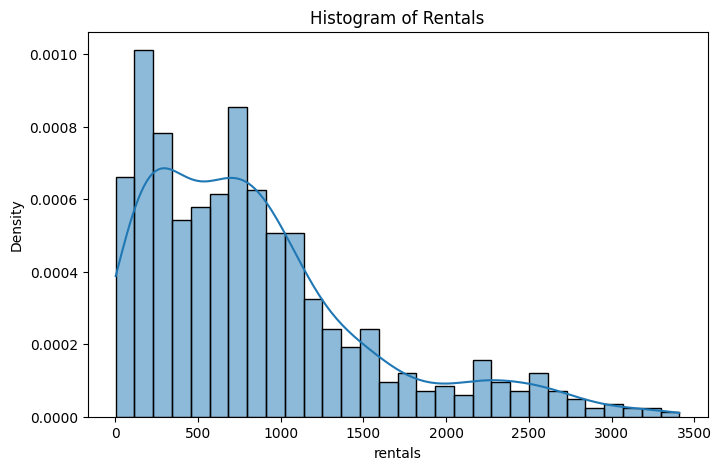

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    data=bike_data_raw,
    x='rentals',
    stat='density',    #density oznacza, że oś Y nie pokazuje liczby obserwacji, tylko gęstość prawdopodobieństwa.
    bins=30,
    kde=True    #Ta linia to KDE (Kernel Density Estimation) — czyli wygładzona estymacja rozkładu danych.
)

plt.xlabel('rentals')
plt.ylabel('Density')
plt.title('Histogram of Rentals')

plt.show()

Nasze dane niewątpliwie są szeregiem czasowym (choć my po feature enginnering podejdziemy do problemu jak do typowego problemu regresji). Najlepiej zobaczyć jak liczba wypożyczeń zmieniała się w czasie. Dodajemy do wykresu również średnią kroczącą z ostatnich 30 dni. Jest to przydatne, jeśli pomiędzy poszczególnymi dniami są spore zależności.

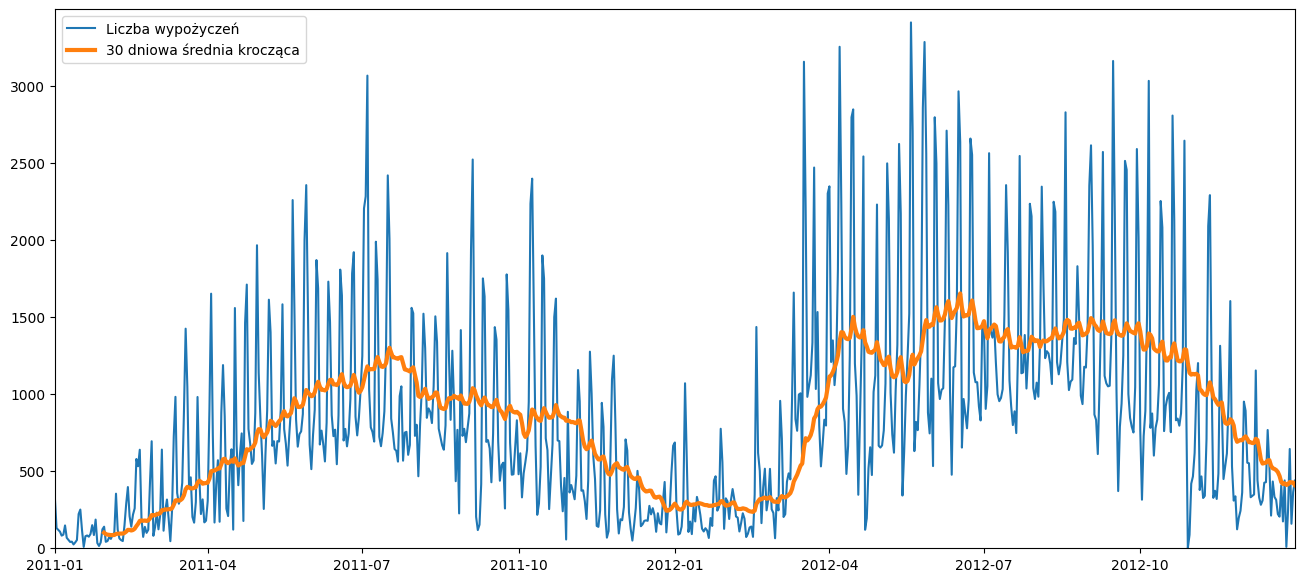

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tworzy nową figurę (obszar wykresu) o rozmiarze 16x7 cali
plt.figure(figsize=(16, 7))

# Rysuje liniowy wykres liczby wypożyczeń w czasie
# Oś X -> data
# Oś Y -> liczba wypożyczeń
# label -> nazwa serii wyświetlana w legendzie
plt.plot(
    bike_data_raw['dteday'],
    bike_data_raw['rentals'],
    label='Liczba wypożyczeń'
)

# Rysuje 30-dniową średnią kroczącą dla liczby wypożyczeń
# rolling(30) -> okno 30 dni
# mean() -> średnia z tych 30 dni
# linewidth=3.0 -> grubsza linia
plt.plot(
    bike_data_raw['dteday'],
    bike_data_raw['rentals'].rolling(30).mean(),
    linewidth=3.0,
    label='30 dniowa średnia krocząca'
)

# Ustawia zakres osi X:
# od najmniejszej do największej daty w datasetcie
plt.xlim([
    bike_data_raw['dteday'].min(),
    bike_data_raw['dteday'].max()
])

# Ustawia zakres osi Y:
# od 0 do maksymalnej liczby wypożyczeń + 2.5% zapasu
# dzięki temu wykres nie "dotyka" górnej krawędzi
plt.ylim([
    0,
    bike_data_raw['rentals'].max() * 1.025
])

# Wyświetla legendę w lewym górnym rogu wykresu
plt.legend(loc='upper left')

# Wyświetla gotowy wykres
plt.show()

Co możemy wywnioskować, patrząc na ten wykres? Przede wszystkim widać sporą wariancję, jest znaczna różnica pomiędzy najwyższa a najniższą wartością w krótkim okresie. Hm… Z czego to może wynikać? Sprawdźmy częstotliwość. Jak to zrobić? Możesz policzyć ilość wzrostów w jednym roku. Zobaczysz, że częstotliwość jest tygodniowa. Z pewnością jeździsz rowerem, z czego to może wynikać? Na przykład z tego, że w weekendy dla relaksu więcej osób wypożycza rower. Jednak my jeszcze tego nie wiemy, dopiero będziemy to sprawdzać. Powód może być zupełnie inny, w dni robocze jest więcej wypożyczeń, ponieważ rowery są traktowane jako środek transportu. Niemniej już teraz możemy stwierdzić, że istnieje sezonowość tygodniowa.

Uff… Całe szczęście, że na wykresie również znalazła się średnia ruchoma ???? Tym zabiegiem zniwelowaliśmy wariancję i możemy sprawdzić jaka jest średnia wypożyczeń w czasie. Można było spodziewać się, że w okresie wakacyjnym zdecydowanie więcej jest wypożyczeń, niż w okresie zimowym.

Jesteśmy na etapie eksploracji danych, ale już teraz zdecydować możemy o usunięciu niektórych kolumn:

instant – unikalny indeks wiersza, ta zmienna nie jest informatywna,
dteday – data, informacje z tej cechy są już zawarte w innych cechach,
yr – rok 2011 już nie wróci.

In [44]:
print('Przed usunięciem:')
display(bike_data_raw)
print('Po usunięciu:')
bike_data = bike_data_raw.copy()
bike_data.drop(['instant', 'dteday', 'yr'], axis=1, inplace=True)
display(bike_data)


Przed usunięciem:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364


Po usunięciu:


,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals
0,1,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331
1,1,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131
2,1,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120
3,1,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108
4,1,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82
...,...,...,...,...,...,...,...,...,...,...,...
726,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247
727,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644
728,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159
729,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364


Hola, hola... Dlaczego na przykład miesiąc to zmienna kategoryczna? Przecież mamy wartości od 1 do 12. Już tłumaczymy, jeśli potraktowalibyśmy tak tę zmienną to wprowadzilibyśmy zakłamanie rzeczywistości. Dla modelu wartość 12 jest daleko od wartości 1, zaś w rzeczywistości po grudniu następuje styczeń. Innym powodem jest również nieliniowość – w miesiącach będących w środku roku jest średnio więcej rowerzystów niż na początku czy na końcu roku. Trzecim powodem jest, że mamy 12 unikalnych wartości dla zmiennej mnth, zatem nie jest to wiele. W związku z tym lepiej będzie jak uznamy tę zmienną za kategoryczną. Jeśli nie jest to dla Ciebie w pełni jasne, spytaj Mentora!

Chodzi o to, że nie każda liczba w danych powinna być traktowana przez model jako „normalna liczba matematyczna”.

Miesiąc (mnth) ma wartości 1–12, ale:

to nie jest prawdziwa skala liczbowa,
tylko etykiety miesięcy.
Problem 1 — „odległość” między miesiącami

Jeśli model potraktuje miesiąc jako liczbę:

styczeń = 1
luty = 2
...
grudzień = 12

to uzna, że:

12 jest bardzo daleko od 1

bo matematycznie:

12 - 1 = 11

Ale w rzeczywistości:

po grudniu jest styczeń,
więc te miesiące są „obok siebie”.

Czyli dane mają charakter cykliczny.

Problem 2 — model zakłada liniowość

Jeśli miesiąc jest liczbą, model może próbować znaleźć zależność typu:

im większy miesiąc → tym więcej wypożyczeń

czyli:

rentals = a * mnth + b

Ale rzeczywistość wygląda bardziej tak:

zima -> mało
wiosna -> więcej
lato -> dużo
jesień -> mniej

Czyli wykres przypomina falę/dzwon, a nie linię.

Dlaczego kategoria pomaga?

Gdy potraktujesz miesiąc jako kategorię:

model nie zakłada odległości,
nie zakłada liniowości,
każdy miesiąc dostaje własne znaczenie.

Przykładowo:

miesiąc	średnie rentals
styczeń	100
luty	120
lipiec	500
grudzień	90

Model uczy się:

„lipiec ma dużo wypożyczeń”,
„grudzień ma mało”,
bez matematycznego założenia:
„12 > 1 więc powinno być więcej”.
Jak modele widzą kategorię?

Najczęściej przez One-Hot Encoding:

mnth	mnth_1	mnth_2	mnth_3	...
1	1	0	0	...
7	0	0	0	...

Wtedy:

miesiące są niezależne,
nie ma „odległości” między nimi.
Kiedy liczby NIE są liczbami?

To bardzo ważna idea w ML.

Te zmienne wyglądają jak liczby, ale są kategoriami:

zmienna	dlaczego kategoria
miesiąc (1–12)	cykliczność
dzień tygodnia (1–7)	poniedziałek ≠ „mniej” niż wtorek
kod pocztowy	identyfikator
ID klienta	identyfikator
numer produktu	etykieta
A co jeśli chcemy zachować cykliczność?

Czasem robi się lepsze kodowanie:

sin(2π * month / 12)
cos(2π * month / 12)

Wtedy:

grudzień i styczeń są blisko siebie,
model rozumie „okrągłość” czasu.

To często stosuje się w bardziej zaawansowanych modelach ML.

uż rozumiemy jak wygląda rozkład naszej zmiennej objaśnianej oraz mamy wyobrażenie od czego jest zależna, ale nadal jest to tylko wyobrażenie. Teraz przyszła kolej na zrozumienie pozostałych cech, oraz jak od nich zależy liczba wypożyczonych jednośladów. Podzielmy zmienne na numeryczne i kategoryczne oraz wskażmy, że targetem jest zmienna rentals.

In [45]:
numeric_features = ['temp', 'atemp', 'hum', 'windspeed']
categorical_features = ['season','mnth','holiday','weekday','workingday','weathersit']
target = 'rentals'


In [46]:
bike_data.columns

Index(['season', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit',
       'temp', 'atemp', 'hum', 'windspeed', 'rentals'],
      dtype='object')

Jak w najprostszy sposób zobaczyć, czy wraz ze wzrostem jednej cechy jest również tendencja dla innej cechy? Jednym z pomysłów może być wykres punktowy. Przejdźmy w pętli przez zmienne numeryczne i zróbmy wykres rentals od tych właśnie zmiennych.

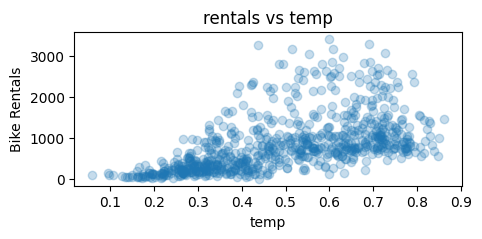

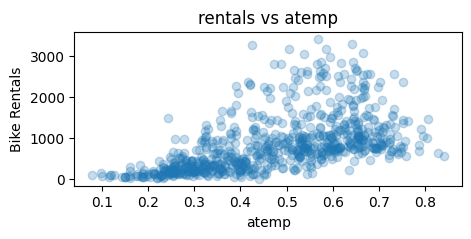

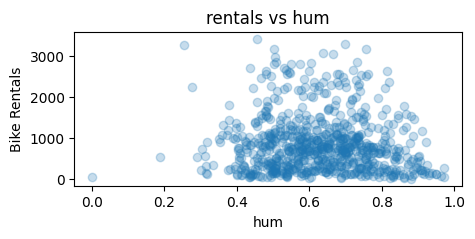

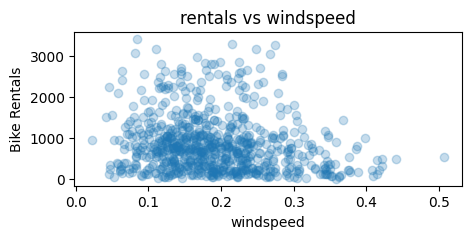

In [47]:
for numeric_feature in numeric_features:  # Pętla przechodząca po wszystkich zmiennych numerycznych

    fig = plt.figure(figsize=(5, 2))  # Tworzy nową figurę o rozmiarze 5x2 cale

    plt.scatter(  # Tworzy wykres punktowy (scatter plot)
        bike_data[numeric_feature],  # Dane na osi X -> aktualna zmienna numeryczna
        bike_data[target],  # Dane na osi Y -> zmienna target (rentals)
        alpha=0.25  # Ustawia przezroczystość punktów
    )

    plt.xlabel(numeric_feature)  # Ustawia nazwę osi X

    plt.ylabel('Bike Rentals')  # Ustawia nazwę osi Y

    plt.title(f'rentals vs {numeric_feature}')  # Ustawia tytuł wykresu

    plt.show()  # Wyświetla wykres

Dla przypomnienia, zmienne numeryczne są już znormalizowane. Temperatura oraz temperatura odczuwalna niosą tę samą informację. Wydaje się również, że to od niej najbardziej jest zależna liczba wypożyczonych rowerów. Im cieplej, tym też więcej rowerzystów. Zależność jest liniowa, jednak od pewnej temperatury liczba rowerzystów spada. Świetnie się jeździ rowerem w ciepłe dni, ale już tej przyjemności nie mamy w upały.

Dla wilgotności czy prędkości wiatru zależność wydaje się odwrotna. Im większe wartości, tym mniej rowerzystów.

Zależności mogą również występować pomiędzy cechami, zatem wykorzystajmy do tego pairplot z biblioteki seaborn. Wymiennie w tym module stosujemy korelację i zależność. Wspominaliśmy już, że te dwa pojęcia nie są tym samym, jednak w naszym przypadku wiemy, że korelacja pomiędzy temperaturą a liczbą rowerzystów jest również zależnością. Są takie problemy, w przypadku których każdy z nas ma wiedzę. Wyobraź sobie kiedy wolisz jeździć rowerem. Jeśli występowałaby korelacja pomiędzy liczbą wypożyczonych rowerów a liczbą obejrzanych przez Ciebie filmów na Netfliksie:

#TLUMACZENIE CHATA 

Różnica jest bardzo ważna:

zależność = bardzo szerokie pojęcie,
korelacja = konkretny typ zależności.
1. Zależność (relationship / dependency)

Zależność oznacza po prostu:

jedna zmienna ma jakiś związek z drugą.

Jeśli zmiana jednej cechy wpływa lub jest powiązana ze zmianą drugiej → mamy zależność.

Może być:

liniowa,
nieliniowa,
rosnąca,
malejąca,
cykliczna,
bardzo skomplikowana.
Przykład zależności nieliniowej

Temperatura a liczba rowerzystów:

bardzo zimno -> mało rowerzystów
umiarkowanie ciepło -> dużo rowerzystów
bardzo gorąco -> znowu mniej

To jest zależność.

Ale niekoniecznie dobra korelacja liniowa.

2. Korelacja

Korelacja mierzy:

jak silna jest liniowa zależność między zmiennymi.

Najczęściej chodzi o korelację Pearsona.

Wartości:

korelacja	znaczenie
1	idealna dodatnia
0	brak liniowej korelacji
-1	idealna ujemna
Dodatnia korelacja
temp ↑ -> rentals ↑

Im cieplej, tym więcej wypożyczeń.

Ujemna korelacja
windspeed ↑ -> rentals ↓

Im większy wiatr, tym mniej rowerzystów.

Najważniejsze:
Można mieć zależność bez korelacji

To kluczowa rzecz.

Przykład:

y = x²
y=x
2

Dla:

x = -2 → y = 4
x = 0 → y = 0
x = 2 → y = 4

Jest bardzo silna zależność.

Ale korelacja liniowa może wyjść bliska 0, bo:

wykres jest parabolą,
nie linią prostą.
Intuicja
Korelacja pyta:
czy punkty układają się w linię?
Zależność pyta:
czy zmienne są ze sobą powiązane w jakikolwiek sposób?
Dlaczego w praktyce ludzie czasem używają zamiennie?

Bo w wielu prostych datasetach:

zależność jest mniej więcej liniowa,
więc korelacja dobrze ją opisuje.

Np.:

temperatura ↔ rentals
wilgotność ↔ rentals

Wtedy:

korelacja rzeczywiście pokazuje zależność.

Ale technicznie:

korelacja ⊂ zależność
czyli korelacja jest tylko jednym rodzajem zależności.

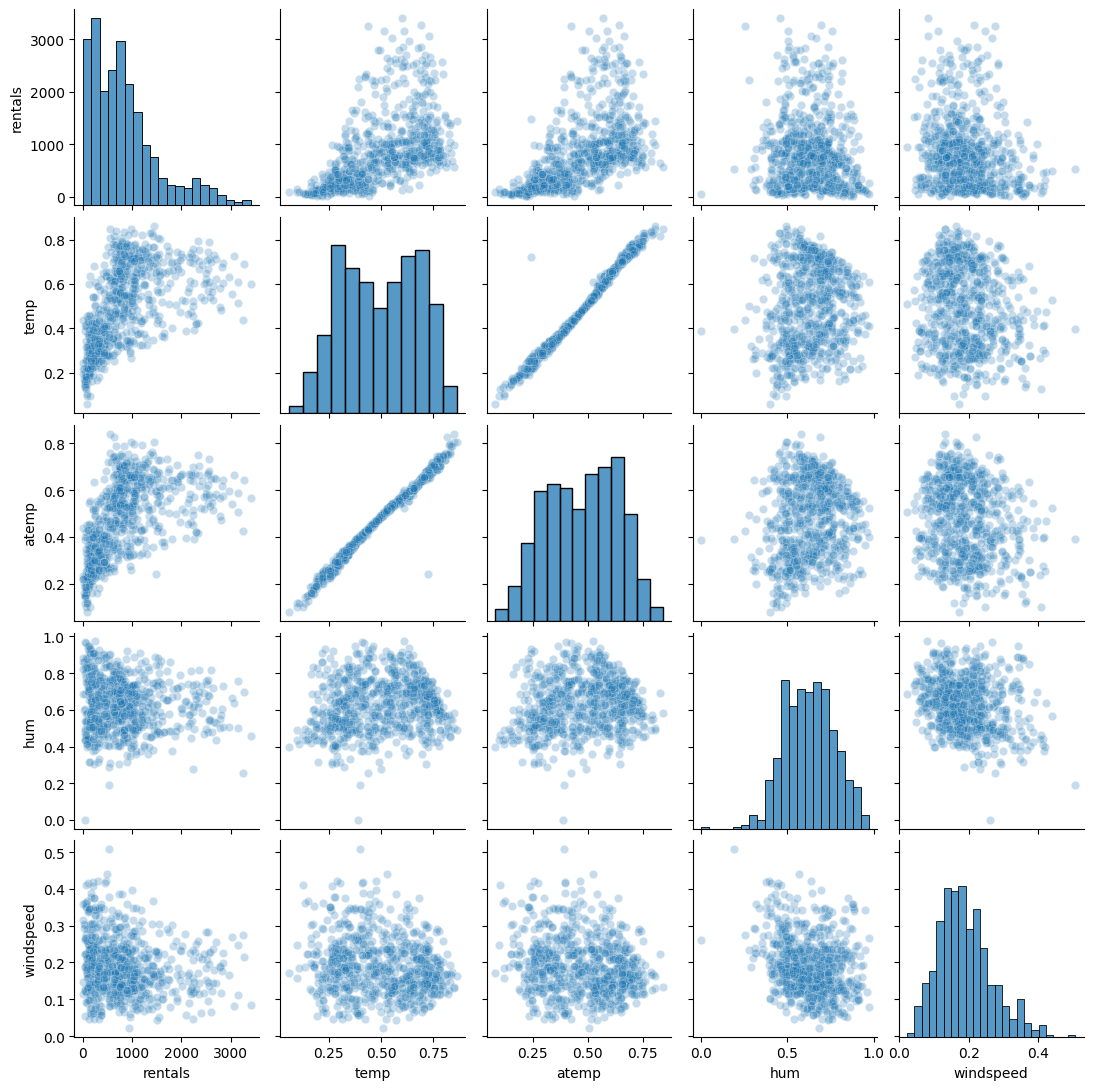

In [48]:
# Tworzy pairplot (siatkę wykresów) dla targetu i zmiennych numerycznych
fig = sns.pairplot(
    bike_data[[target] + numeric_features],  # Wybiera kolumnę target oraz wszystkie zmienne numeryczne
    kind='scatter',  # Typ wykresów -> scatter plot (wykres punktowy)
    plot_kws={'alpha': 0.25}  # Ustawia przezroczystość punktów
)

# Ustawia rozmiar całej figury na 11x11 cali
fig.fig.set_size_inches(11, 11)

# Wyświetla wykres
plt.show()

Dodaliśmy tu również zmienną rentals, a zatem poprzedni scatter plot moglibyśmy zastąpić tym. Pamiętaj, jedną rzecz można wykonać na wiele sposób. Zmienne są względem siebie niezależne poza temperaturą i temperaturą odczuwalną. Te dwie cechy niosą tę samą informację, jedną z nich będziemy mogli później usunąć.

Wspominaliśmy już o korelacji, nastąpił moment, by tę korelację wyliczyć i porównać z poprzednimi wykresami.

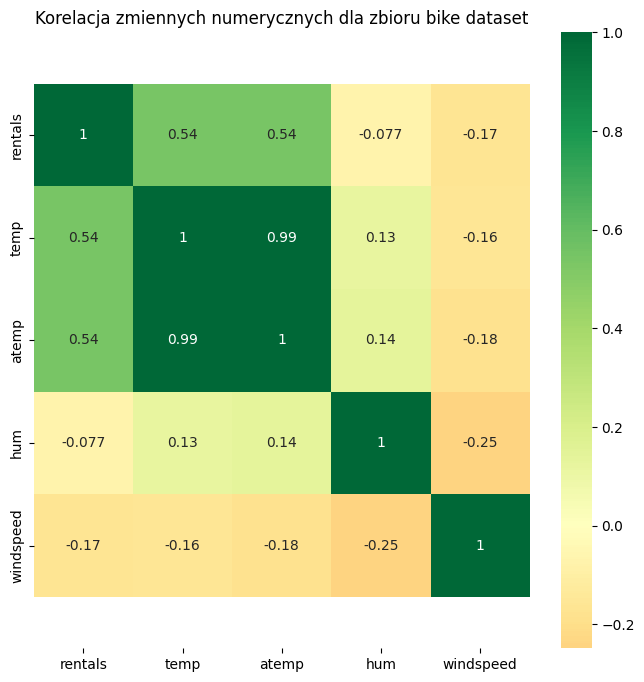

In [49]:
# Tworzy nową figurę o rozmiarze 8x8 cali
plt.figure(figsize=(8, 8))

# Tworzy mapę ciepła (heatmap) macierzy korelacji
ax = sns.heatmap(

    # Oblicza korelację dla targetu i zmiennych numerycznych
    bike_data[[target] + numeric_features].corr(),

    # Ustawia etykiety osi X jako nazwy kolumn
    xticklabels=bike_data[[target] + numeric_features].corr().columns,

    # Ustawia etykiety osi Y jako nazwy kolumn
    yticklabels=bike_data[[target] + numeric_features].corr().columns,

    # Ustawia kolorystykę heatmapy:
    # czerwony -> ujemna korelacja
    # żółty -> około 0
    # zielony -> dodatnia korelacja
    cmap='RdYlGn',

    # Ustawia środek skali kolorów na 0
    center=0,

    # Wyświetla wartości korelacji wewnątrz komórek
    annot=True
)

# Ustawia tytuł wykresu
plt.title(
    'Korelacja zmiennych numerycznych dla zbioru bike dataset',
    fontsize=12
)

# Pobiera aktualne granice osi Y
bottom, top = ax.get_ylim()

# Koryguje granice osi Y
# dzięki temu pierwszy i ostatni wiersz heatmapy nie są obcięte
ax.set_ylim(bottom + 0.5, top - 0.5)

# Ustawia rozmiar czcionki etykiet osi X
plt.xticks(fontsize=10)

# Ustawia rozmiar czcionki etykiet osi Y
plt.yticks(fontsize=10)

# Wyświetla gotowy wykres
plt.show()

Wnioski te same, które wyciągnęliśmy wcześniej.

1 Liczba rowerzystów jest najbardziej zależna od temperatury.
2 Wilgotność oraz prędkość wiatru mają mniejszy wpływ niż temperatura, korelacja jest ponadto ujemna.
3 Temperatura oraz temperatura odczuwalna niosą tę samą informację.

Inżynieria cech została już wykonana na podstawie zmiennych związanych z datą. Co zatem możemy zrobić, jeśli mamy dwie zmienne skorelowane ze sobą. Z pomocą przychodzi nam PCA (Analiza głównych składowych), lecz ten algorytm poznasz na zajęciach z uczenia nienadzorowanego. Innym pomysłem jest po prostu usunięcie jednej z temperatur. W Data Science czasem wygrywa POMYSŁ i my z tego skorzystamy. Obliczmy różnicę pomiędzy temperaturą odczuwalną a temperaturą i wyskalujmy, korzystając z temperatury zgodnie z poniższym wzorem:



atemp-temp/temp

In [50]:
bike_data['difference_temp'] = (bike_data['atemp'] - bike_data['temp'])/bike_data['temp']
bike_data.drop(['atemp'], axis=1, inplace=True)
numeric_features = ['temp', 'difference_temp', 'hum', 'windspeed']
bike_data[['rentals', 'temp', 'difference_temp']].corr()


,rentals,temp,difference_temp
rentals,1.000000,0.543285,-0.310423
temp,0.543285,1.000000,-0.599254
difference_temp,-0.310423,-0.599254,1.000000


Nasza nowa zmienna jest skorelowana również z temperaturą, jednak nie tak bardzo oraz niesie informację, która pomoże naszemu modelowi.

Teraz przejdźmy do zmiennych kategorycznych. Dobrym sposobem jest sprawdzenie średniej w zależności od kategorii, a jeszcze lepszym jest sprawdzenie rozkładu zmiennej objaśnianej w zależności od kategorii.

Dobrym sposobem będzie Box-plot, lecz przejdziemy o krok dalej - stworzymy wykres skrzypcowy, na którym jest więcej informacji. Aby uzyskać podobny wykres moglibyśmy stworzyć Box-plot oraz wizualizować rozkład, wykorzystując histogramy w zależności od kategorii.

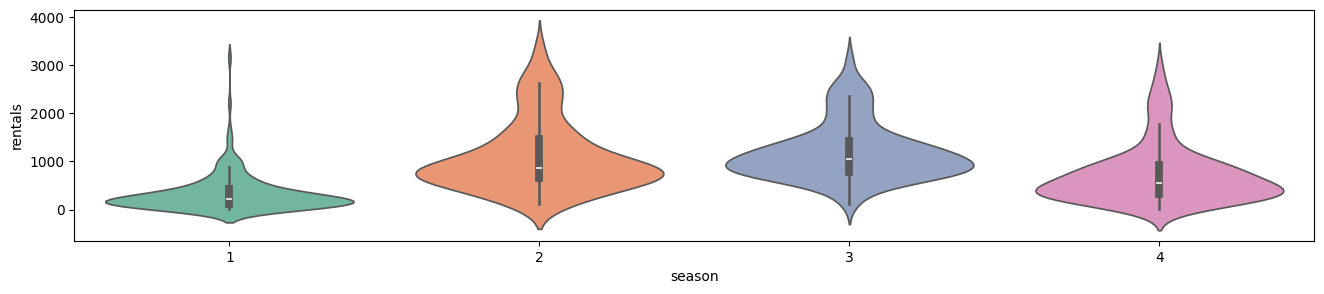

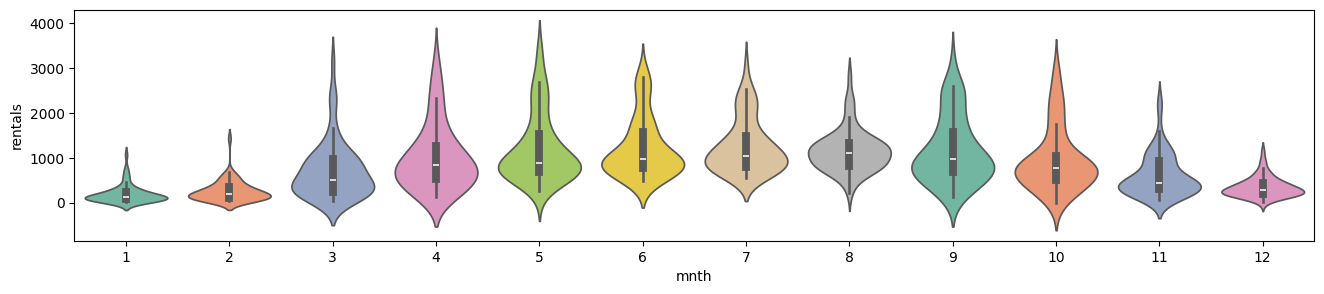

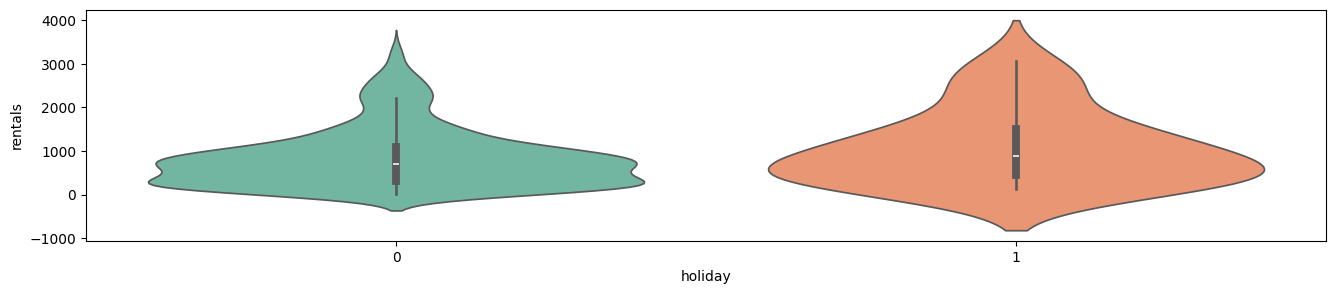

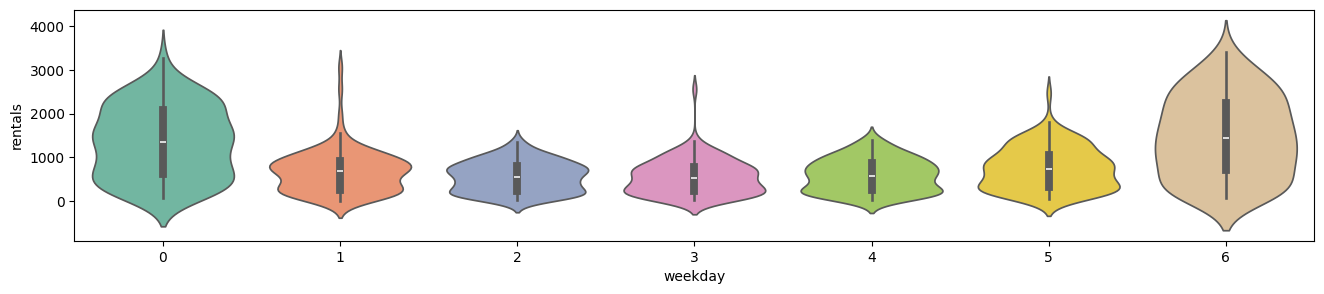

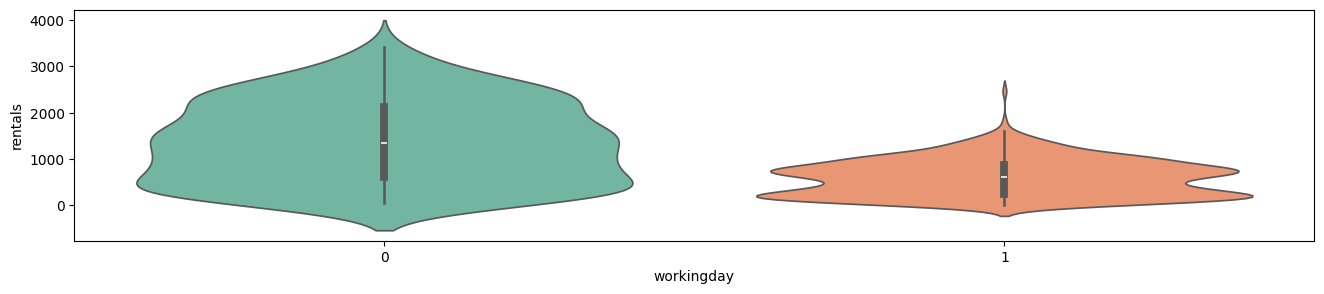

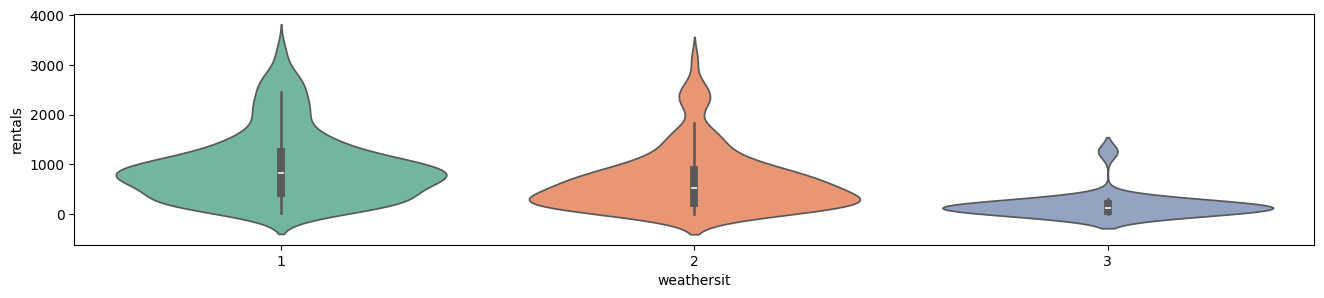

In [51]:
for categoric_feature in categorical_features:  # iteracja po wszystkich zmiennych kategorycznych
    plt.figure(figsize=(16, 3))  # utworzenie nowego wykresu o rozmiarze 16x3 cali

    sns.violinplot(  # utworzenie wykresu skrzypcowego
        data=bike_data,  # źródło danych
        x=categoric_feature,  # zmienna kategoryczna na osi X
        y=target,  # zmienna docelowa na osi Y
        hue=categoric_feature,  # przypisanie kolorów do kategorii
        palette="Set2",  # paleta kolorów
        legend=False  # wyłączenie legendy
    )

    plt.show()  # wyświetlenie wykresu

# WNIOSKI 

#season
Wiosną, latem i jesnienia liczba wypozyczeń rowerów jest podobna i jest ona przeciętnie wyższa niż w sesonie zimowym.

#months Od Marca do Października/Listopada liczba wypożyczanych rowerów jest podobna, natomiast w miesiącach zimowych (grudzień, styczeń , luty) jest wyraźnie niższa

#holidays Podczas wakacji liczba wypozyczen jest wieksza ale nie ma to kluczowego wplywu

#weekday W weekendy liczba wypozyczen jest zdecydowanie wyzsza. W pozostale dni tygodnia jest na porownywalnym poziomie

#workingday Widac zdecydowana roznice w wygladzie wykresu. W dni wolne od pracy liczba wypozyczen jest zdecydowanie wyzna i ma wplyw na wartosc zmiennej docelowej.

#weathersit Warunki pogodowe maja wplyw na liczbe wypozyczen, widac zdecydowana roznice pomiedzy kategoria 1 i 2 gdzie liczba wypozyczen jest porownywalnie duza , a kategoria numer 3 ( najgorsze warunki pogodowe) gdize liczba wypozyczen jest zdecydowanie mniejsza.

# Regresja liniowa jednej zmiennej

Poznaliśmy problem do rozwiązania, zweryfikowaliśmy dane oraz udało nam się je przekształcić, choć to w dużej mierze zostało to już wykonane we wczytanym przez nas zbiorze. Czym jest regresja liniowa dowiedzieliśmy się już wcześniej, przejdźmy do praktycznej części i stwórzmy taki model. Musimy teraz określić, czym jest X, a czym y. W naszym przypadku - X to zmienna, na podstawie której dokonujemy predykcji, y - zmienna, którą chcemy prognozować.

Spójrzmy raz jeszcze na nasz zbiór danych

In [52]:
print(f'Numeric features: {numeric_features}')
print(f'Categorical features: {categorical_features}')
print(f'Target: {target}')
display(bike_data)


Numeric features: ['temp', 'difference_temp', 'hum', 'windspeed']
Categorical features: ['season', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
Target: rentals


,season,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,rentals,difference_temp
0,1,1,0,6,0,2,0.344167,0.805833,0.160446,331,0.056537
1,1,1,0,0,0,2,0.363478,0.696087,0.248539,131,-0.026794
2,1,1,0,1,1,1,0.196364,0.437273,0.248309,120,-0.035439
3,1,1,0,2,1,1,0.200000,0.590435,0.160296,108,0.060610
4,1,1,0,3,1,1,0.226957,0.436957,0.186900,82,0.010191
...,...,...,...,...,...,...,...,...,...,...,...
726,1,12,0,4,1,2,0.254167,0.652917,0.350133,247,-0.108295
727,1,12,0,5,1,2,0.253333,0.590000,0.155471,644,0.006762
728,1,12,0,6,0,2,0.253333,0.752917,0.124383,159,-0.043157
729,1,12,0,0,0,1,0.255833,0.483333,0.350754,364,-0.094331


Jak się przekonaliśmy, liczba wypożyczonych rowerów jest najbardziej zależna od temperatury występującej danego dnia. Stwórzmy model w oparciu o tę właśnie zmienną. Naszym X będzie temp, zaś y to oczywiście rentals.

In [53]:
X = bike_data[['temp']].copy()  # utworzenie zbioru cech (X) zawierającego tylko kolumnę 'temp' i kopię danych

y = bike_data[target].copy()  # utworzenie zmiennej docelowej (y) na podstawie kolumny target (np. 'cnt')

print('X:')  # wypisanie nagłówka dla danych wejściowych (cech)
print(X.values[:3])  # wyświetlenie pierwszych 3 wartości cechy X w formie tablicy numpy

print('\ny:')  # wypisanie nagłówka dla zmiennej docelowej (oddzielone nową linią)
print(y.values[:3])  # wyświetlenie pierwszych 3 wartości zmiennej docelowej

X:
[[0.344167]
 [0.363478]
 [0.196364]]

y:
[331 131 120]


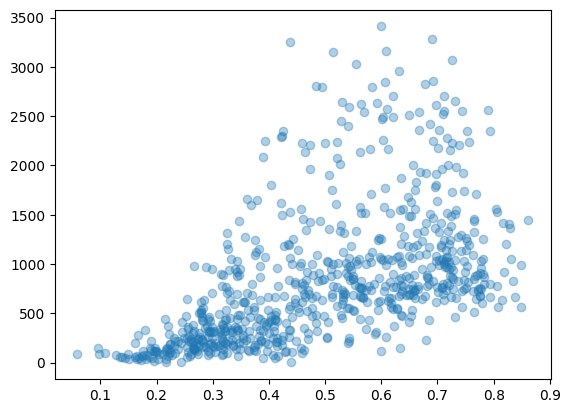

In [54]:
plt.scatter(X, y, alpha=0.35)
plt.show()

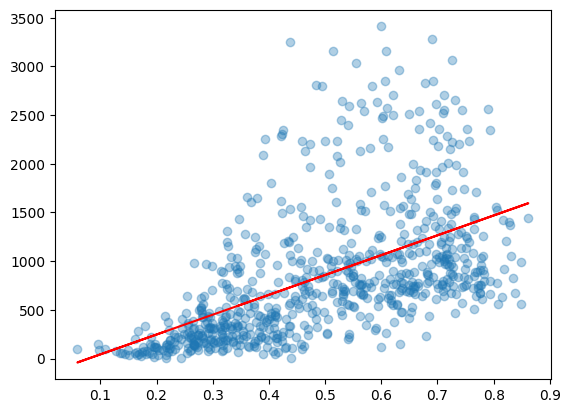

In [55]:
from sklearn.linear_model import LinearRegression  # import modelu regresji liniowej

X = bike_data[['temp']].copy()  # cecha (temperatura)
y = bike_data[target].copy()  # zmienna docelowa (np. liczba wypożyczeń)

model = LinearRegression()  # stworzenie modelu regresji

model.fit(X, y)  # dopasowanie modelu metodą najmniejszych kwadratów (MNK)

y_pred = model.predict(X)  # przewidywania modelu (linia regresji)

plt.scatter(X, y, alpha=0.35)  # punkty danych
plt.plot(X, y_pred, color='red')  # linia regresji
plt.show()  # pokaz wykres

# zbior treningowy i testowy

Zanim zaczniemy uczyć model regresji liniowej, dzielimy nasz zbiór na Train (X_train i y_train) oraz Test (X_test i y_test). Chcemy, aby nasz model potrafił generalizować, a zatem poprawnie prognozował wartości, których nie widział. W związku z tym dzielimy nasze dane na treningowe oraz testowe. Wielkość obu zbiorów zależy od tego ile mamy wszystkich obserwacji. Im jest ich więcej, tym zbiór testowy może być mniejszy. Najczęściej jest to 67 do 33 lub 80 do 20. Uczymy model na zbiorze treningowym, następnie sprawdzamy jego jakość na zbiorze testowym. Jeśli jest on reprezentatywny, to podobnych wyników spodziewać się możemy w finale. Na koniec możemy wytrenować model dla wybranych hiperparametrów na całym zbiorze. Czym są hiperparametry, tego jeszcze się dowiesz.

Aby podzielić nasz zbiór na dane treningowe oraz testowe skorzystamy z funkcji train_test_split, która dostępna jest w sklearn. Podajemy funkcji X i y. Ponadto ustawmy parametr shuffle na False, przez co nie będziemy tasować obserwacji. Zazwyczaj tasujemy, jednak w tym przypadku mamy do czynienia z szeregiem czasowym, gdzie obserwacje są zależne względem siebie. Wartość parametru test_size powinna zawierać się pomiędzy 0.0 a 1.0 i reprezentować część zbioru danych przeznaczonego dla zbioru testowego. Jeśli dla tego parametru podasz liczbę całkowitą (int), to oznaczać będzie bezwzględną liczbę obserwacji w zbiorze testowym. Przeznaczmy dla zbioru testowego 20% danych.

In [56]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print(f'X.shape: {X.shape}, y.shape {y.shape}')
print()
print(f'X_train.shape: {X_train.shape}, y_train.shape {y_train.shape}')
print(f'X_test.shape: {X_test.shape}, y_test.shape {y_test.shape}')

X.shape: (731, 1), y.shape (731,)

X_train.shape: (584, 1), y_train.shape (584,)
X_test.shape: (147, 1), y_test.shape (147,)


W zbiorze treningowym mamy 584 obserwacje, a w zbiorze testowym mamy 174 obserwacje.

Pewnie nie możesz się doczekać nauki pierwszego modelu uczenia maszynowego! Zatem stwórzmy go.

Najpierw musimy zaimportować model, następnie stworzyć instancję z modelem i nauczyć go.

In [57]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression() # inicjalizacja modelu
lr_model.fit(X_train, y_train) # trenowanie modelu

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [58]:
print(lr_model.intercept_)
print(lr_model.coef_)

-179.96286312537404
[1990.31869846]


intercept_ ➝ β0,
coef_ ➝ β1 oraz kolejne (jeśli zmiennych objaśniających jest więcej).

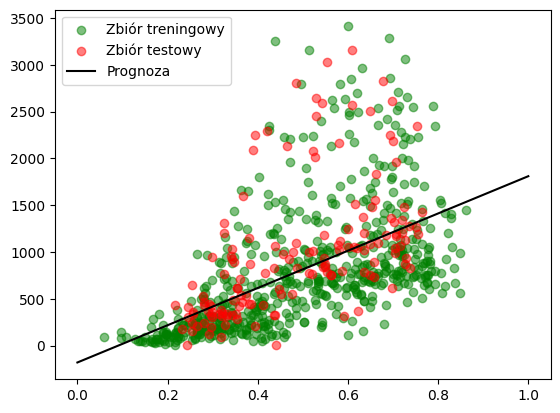

In [59]:
import numpy as np  # import biblioteki NumPy do operacji numerycznych

X_linspace = np.linspace(0, 1, 100)  
# tworzy 100 równomiernie rozłożonych punktów od 0 do 1 (oś X dla prostej regresji)

y_fitted = lr_model.intercept_ + lr_model.coef_ * X_linspace  
# wyznaczenie wartości linii regresji:
# y = β0 + β1 * x
# intercept_ = β0 (wyraz wolny)
# coef_ = β1 (nachylenie prostej)

# Rysowanie wykresu
plt.scatter(X_train, y_train, color='green', alpha=0.5, label='Zbiór treningowy')  
# punkty danych treningowych

plt.scatter(X_test, y_test, color='red', alpha=0.5, label='Zbiór testowy')  
# punkty danych testowych

plt.plot(X_linspace, y_fitted, color='black', label='Prognoza')  
# linia regresji liniowej wyznaczona metodą najmniejszych kwadratów

plt.legend(loc='upper left')  
# legenda w lewym górnym rogu wykresu

plt.show()  
# wyświetlenie wykresu

Możesz zauważyć, że dla najmniejszej możliwej wartości temperatury prognoza może być mniejsza niż wartość 0. Oczywiście taka sytuacja nie jest możliwa, zatem warto, aby na produkcji wprowadzić warunek, że jeśli prognoza jest mniejsza niż 0, to powinna być równa 0.

Teraz sprawdźmy, jak wykonać prognozę na nowych danych, ponieważ zawsze to jest naszym celem.

In [100]:
X_new = [[0.3],
         [0.7]]
predicted_data = lr_model.predict(X_new)
predicted_data_rounded = np.round(predicted_data,2)
print(predicted_data_rounded)

[ 417.13 1213.26]


C:\Users\micha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# ten wynik wyzej oznacza ze dla temperatury 0.3 przewiduje 417.13 wypozyczen a dla 0.7 - 1213.26

Skąd to się bierze?

Twój model regresji liniowej działa według wzoru:

y=β
0
	​

+β
1
	​

⋅x

czyli:

wynik = intercept_ + coef_ * temp

Czyli:

intercept_ → punkt startowy (gdy temp = 0)
coef_ → jak bardzo rośnie liczba wypożyczeń wraz z temperaturą
📈 Dlaczego jeden wynik jest dużo większy?

Bo model nauczył się zależności:

im wyższa temperatura, tym więcej wypożyczeń rowerów

więc:

0.3 → chłodniej → mniej wypożyczeń (~417)
0.7 → cieplej → więcej wypożyczeń (~1213)
⚠️ Ważna rzecz (częsty błąd)

Twoje temp jest prawdopodobnie:

znormalizowane (0–1)

czyli:

0 = zimno
1 = bardzo ciepło

Dlatego wartości 400–1200 są sensowne w kontekście datasetu Bike Sharing.

In [101]:
print(lr_model.intercept_)
print(lr_model.coef_)

-179.96286312537404
[1990.31869846]


🔍 Interpretacja parametrów
🔴 intercept_ = -179.96

To wartość startowa:

gdy temp = 0, model przewiduje około -180 wypożyczeń

❗ To nie ma sensu w rzeczywistości, ale jest normalne w regresji liniowej.

Dlaczego?

model dopasowuje prostą matematycznie
nie jest ograniczony do wartości ≥ 0
🟢 coef_ = 1990.32

To najważniejszy parametr:

gdy temperatura rośnie o 1 (czyli od 0 do 1), liczba wypożyczeń rośnie średnio o ~1990

Czyli:

zimno → mało rowerów
ciepło → dużo rowerów
📈 Przykład działania modelu

Dla temp = 0.3:

y=−179.96+1990.32⋅0.3
y≈417

Dla temp = 0.7:

y≈1213
⚠️ Dlaczego intercept jest ujemny?

To normalne, bo:

dane nie zaczynają się od 0 wypożyczeń
linia musi „przeciąć” oś Y matematycznie najlepiej jak się da
💡 Najważniejszy wniosek

👉 Twój model mówi:

temperatura ma silny, dodatni wpływ na liczbę wypożyczeń rowerów

# OCENA MODELU

In [102]:
y_predict_train = lr_model.predict(X_train)
y_predict_test = lr_model.predict(X_test)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- difference_temp
- holiday
- hum
- mnth
- season
- ...


Teraz będziemy porównywać prognozę naszego modelu z wartościami prawdziwymi. Wyświetlmy 5 pierwszych prognoz oraz wartości prawdziwych dla zbioru testowego.

In [103]:
print('Predykcja:')
print(np.round(y_predict_test[:5]).astype(int))
print('Wartość prawdziwa:')
print(y_test.values[:5])

Predykcja:
[1285 1313 1324 1245 1198]
Wartość prawdziwa:
[1278 1263 1196 1065 2247]


Ciężko jednak porównywać wszystkie obserwacje, tym bardziej, że często zbiory danych są o wiele większe. Wykorzystamy metryki, które agregują prognozy z wartościami prawdziwymi do jednej liczby.

# WSPOLCZYNNIK DETERMINACJI

Gdzie:

yi – wartości prawdziwe,
ŷi – wartości prognozy,
ȳ – średnia z zaobserwowanych obserwacji.
Dla regresji liniowej współczynnik determinacji to podniesiony do drugiej potęgi współczynnik korelacji. Wartości R2 zbliżone do 1, odpowiadają dobremu dopasowaniu modelu, zaś wartości bliskie 0 oznacza niezadowalające dopasowanie. Jak możesz zauważyć we wzorze, w liczniku jest suma kwadratów różnic pomiędzy wartością prawdziwą a prognozą, a w mianowniku pomiędzy wartością prawdziwą a resztą. W związku z powyższym współczynnik determinacji pokazuje o ile lepiej nasz model sobie radzi niż średnia. Innymi słowy, pokazuje jaka część y jest wyjaśniana przez model.

Praktycznie możemy obliczyć R2 dla zbioru testowego, lecz z punktu widzenia Data Science - nie powinniśmy tego robić, ponieważ R2 przekazuje nam informację o ile lepiej nasz model wyjaśnia zmienność niż średnia. Stąd też R2 dla modelu, który jest średnią, daje wynik 0. Ponieważ z założenia nie znamy średniej ze zbioru testowego, to również nie powinniśmy dla tego zbioru liczyć R2.

Sprawdźmy, jaką część zmienności y wyjaśnia nasz model.

In [64]:
from sklearn.metrics import r2_score
print(f'Train R^2: {r2_score(y_train, y_predict_train)}')

Train R^2: 0.30617863454631344


Co to jest R²?

R² (współczynnik determinacji) mówi:

jak dobrze model tłumaczy zmienność danych

W uproszczeniu:

ile „wariancji” (różnic w danych) model potrafi wyjaśnić
📊 Jak interpretować 0.306?
R² = 0.306 ≈ 30.6%

👉 Twój model wyjaśnia tylko ok. 30% zmienności danych

❗ Co to oznacza w praktyce?
✔ model coś „widzi” w danych (jest lepszy niż losowy)
❌ ale większość informacji (~70%) nie jest wyjaśniona
⚠ model jest raczej słaby / niedopasowany
📉 Jak wygląda interpretacja jakości:
R²	Interpretacja
0.0	model jak zgadywanie średniej
0.3	słabe dopasowanie (Twoje)
0.5–0.7	średnie
0.8–1.0	dobre / bardzo dobre
🧠 Dlaczego u Ciebie jest niskie R²?

Bo używasz:

X = temp (jedna zmienna)

A liczba wypożyczeń zależy od wielu rzeczy:

pogody (weathersit)
dnia tygodnia
sezonu
świąt
wilgotności, wiatru itd.

👉 więc jedna zmienna nie wystarcza

💡 Najważniejszy wniosek do raportu:

Model regresji liniowej oparty wyłącznie na temperaturze wyjaśnia około 30% zmienności liczby wypożyczeń rowerów, co oznacza umiarkowaną zależność, ale wskazuje na konieczność uwzględnienia dodatkowych zmiennych w modelu.

# MAE - Mean Absolute Error

Metryka liczy średni błąd procentowy. Różnica w porównaniu do poprzedniej metryki jest taka, że różnicę dzielimy przez wartość prawdziwą. Polubisz tą metrykę, biznes lubi gdy rozmawia się o procentach.

MAPE mówi:

o ile procent średnio model się myli.

    Jak interpretować wynik?

Załóżmy, że dostajesz np.:

Train MAPE: 0.35
Test MAPE: 0.38

To znaczy:

0.35 = 35% średniego błędu
0.38 = 38% średniego błędu
🔴 Jak czytać MAPE:
MAPE	Jakość modelu
< 10%	bardzo dobry
10–20%	dobry
20–50%	średni / słaby
> 50%	bardzo słaby
📌 Co oznacza porównanie Train vs Test?
✔ jeśli podobne:
Train ≈ Test

👉 model generalizuje dobrze

❌ jeśli różne:
Train dużo niższy niż Test

👉 overfitting

⚠️ Ważne ostrzeżenie (MAPE)

MAPE ma problem gdy:

y_true = 0 (dzielenie przez 0)
bardzo małe wartości → duże błędy %
🧠 Jak to interpretować u Ciebie (Bike Sharing)

Jeśli masz np.:

Train MAPE = 0.30
Test MAPE = 0.32

To znaczy:

model myli się średnio o ~30% w prognozie liczby wypożyczeń rowerów

💡 Gotowy wniosek do raportu:

Model osiąga średni błąd procentowy na poziomie około X%, co oznacza umiarkowaną dokładność predykcji. Podobne wartości MAPE dla zbioru treningowego i testowego wskazują, że model nie wykazuje silnego overfittingu, jednak jego precyzja jest ograniczona.

In [65]:
from sklearn.metrics import mean_absolute_percentage_error
print(f'Train MAPE: {mean_absolute_percentage_error(y_train, y_predict_train)}')
print(f'Test MAPE: {mean_absolute_percentage_error(y_test, y_predict_test)}')

Train MAPE: 0.9668581511778538
Test MAPE: 2.9864925318560496


Średnio mylimy się prawie o 300%. Lepiej prognozujemy niż średnia, jednak chyba uznasz, że jeszcze nie jest dobrze.

Interpretacja (bardzo ważne)

To są bardzo złe wyniki modelu.

👉 model myli się średnio:

prawie o wartość samej zmiennej (train)
i prawie 3× wartość rzeczywistą (test)
📊 Co mówi porównanie Train vs Test?
Train ≈ 0.97
Test ≈ 2.99

👉 ogromna różnica

❗ Wniosek:
model nie generalizuje
działa znacznie gorzej na nowych danych
możliwy overfitting lub źle dobrany model / cechy

# MSE - Mean Squared Error

Średni błąd kwadratowy. Istotne dla tej metryki jest, że błędy podnoszone są do drugiej potęgi. Z tego powodu ta metryka jest wrażliwa na wysokie błędy, a to jest jej przewaga nad MAE. Wadą jest, że wartości nie są dla nas zrozumiałe. Przez to, że błędy podnoszone są do kwadratu, to nie są wyrażane w procentach czy w wartościach wypożyczonych rowerów.

In [66]:
from sklearn.metrics import mean_squared_error
print(f'Train MSE: {mean_squared_error(y_train, y_predict_train)}')
print(f'Test MSE: {mean_squared_error(y_test, y_predict_test)}')

Train MSE: 317745.94124252343
Test MSE: 397066.9447179113


Jak rozumieć powyższe wartości? Właśnie, jest to wada powyższej metryki, którą następna metryka niweluje.

# RMSE – Root Mean Squared Error

Pierwiastek błędu średniokwadratowego. Dzięki temu, że wyliczamy metrykę z MSE, otrzymujemy nową metrykę, porównywalną do MAE. RMSE nie może być mniejsze niż MAE, a różnica pomiędzy nimi świadczy o skali dużych błędów. Załóżmy, że dla pewnego zbioru błąd absolutny jest ten sam, wtedy też metryka RMSE będzie równa MAE.

In [67]:
from math import sqrt
print(f'Train RMSE: {sqrt(mean_squared_error(y_train, y_predict_train))}')
print(f'Test RMSE: {sqrt(mean_squared_error(y_test, y_predict_test))}')

Train RMSE: 563.6895787953894
Test RMSE: 630.1324818781454


RMSE (Root Mean Squared Error) to:

średni błąd modelu w tych samych jednostkach co dane

Czyli u Ciebie:

👉 liczba wypożyczeń rowerów

📊 Jak to interpretować?
🔴 Train RMSE = 564

Model na danych treningowych myli się średnio o:

~564 wypożyczenia

🔴 Test RMSE = 630

Na nowych danych myli się o:

~630 wypożyczeń

❗ Co to oznacza?
✔ najważniejsze:
wyniki trening i test są podobne
więc model nie jest mocno przeuczony
❌ ale:
błąd jest dość duży
model ma słabą dokładność
📉 Jak to wygląda w praktyce?

Jeśli prawdziwa wartość to np.:

1000 wypożyczeń

to błąd 600 oznacza:

👉 model może trafić np. 400 albo 1600

czyli:

spora niepewność prognozy

📊 Interpretacja jakości:
RMSE	Jakość
< 100	bardzo dobry
100–300	dobry
300–600	średni
> 600	słaby

👉 Twój test RMSE = 630 → raczej słaby model

# Wizualizacyjna ocena modelu

Poznaliśmy najczęściej stosowane metryki oceny do problemu regresji. Jak widzisz nie jest to rocket science, metryki są proste do policzenia, jak i do zrozumienia. Z pewnością widzisz już różnice pomiędzy nimi, jak i wady oraz zalety.

Metryki poznane przez Ciebie przed chwilą nadal nie przekazują wszystkich informacji o jakości modelu, na przykład czy model przeszacowuje czy niedoszacowuje. Sprawdźmy na podstawie już wytrenowanego algorytmu użyteczne wizualne metody oceny modelu.

# Porównanie wartości prawdziwej z predykcją


Robimy wykres punktowy dla prognozy oraz wartości prawdziwej. Wartości x (prognoza) powinna być taka sama co y (wartość prawdziwa). Wizualizacja pokazuje ogólny obraz jakości prognozy, dążymy do tego, aby punkty były jak najbliżej oczekiwanej linii trendu.



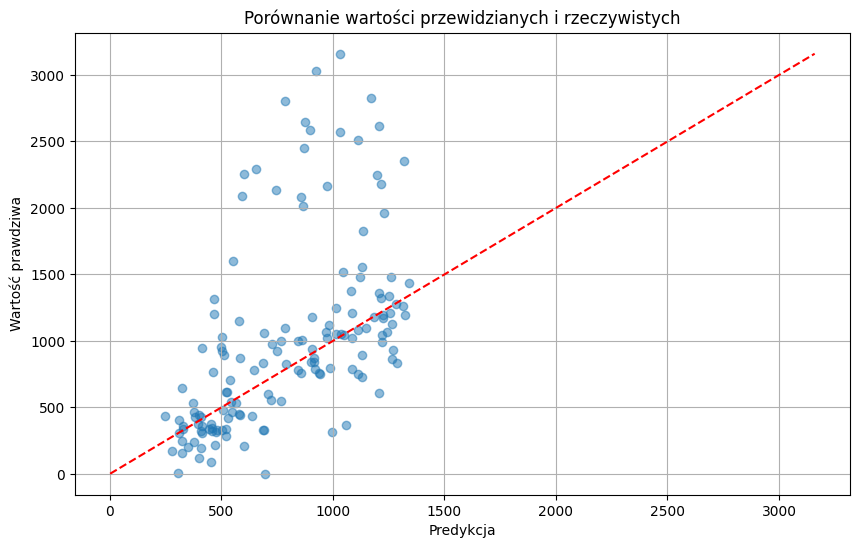

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# Zaokrąglenie predykcji do najbliższej liczby całkowitej
y_pred = np.round(y_predict_test).astype(int)

# Utworzenie wykresu
plt.figure(figsize=(10, 6))

# Wykres punktowy:
# oś X - wartości przewidziane przez model
# oś Y - wartości rzeczywiste
plt.scatter(
    y_pred,
    y_test.values,
    alpha=0.5
)

# Wyznaczenie minimalnej i maksymalnej wartości do narysowania linii referencyjnej
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

# Linia idealnych predykcji (y = x)
# Punkty leżące na tej linii oznaczają idealne dopasowanie modelu
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
)

# Opisy osi
plt.xlabel('Predykcja')
plt.ylabel('Wartość prawdziwa')

# Tytuł wykresu
plt.title('Porównanie wartości przewidzianych i rzeczywistych')

# Dodanie siatki pomocniczej
plt.grid(True)

# Wyświetlenie wykresu
plt.show()

# Wykres reszt

Jak widzisz na wykresie poprzedzającym, dla wartości prawdziwej model niedoszacowuje wysokich wartości. Z pomocą przychodzi nam wykres reszt. Powinien przypominać chmurę, wtedy można uznać, że błędy wynikają z szumu w danych. Jeśli na wykresie reszt można doszukać się zależności to znaczy, że nie w pełni wyjaśniona została zmienność.

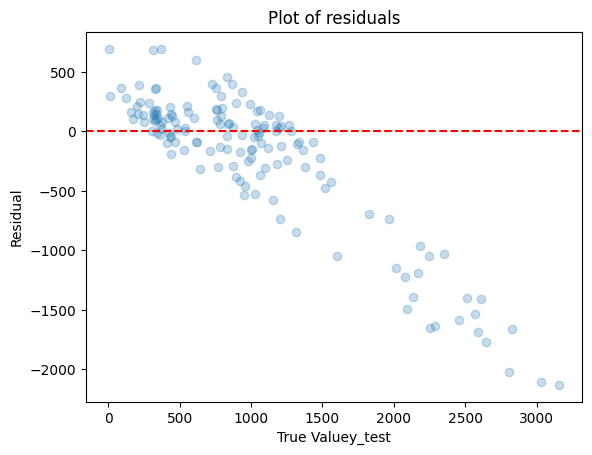

In [69]:
errors = y_predict_test - y_test
plt.scatter(x = y_test, y = errors, alpha=0.25)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel('True Valuey_test')
plt.ylabel('Residual')
plt.title(f'Plot of residuals')
plt.show()

Na powyższym wykresie bardzo zauważalna jest zależność. Im wyższe wartości prawdziwe, tym coraz bardziej model niedoszacowuje

# Histogram reszt

Pokazuje czy i w jaką stronę model jest obiążony (Bias), tj. czy średnia reszt jest przesunięta względem zera (wtedy przeszacowujemy bądź niedoszacowujemy) oraz czy rozkład reszt jest np. skośny (nie w pełni wyjaśniamy wariancję).

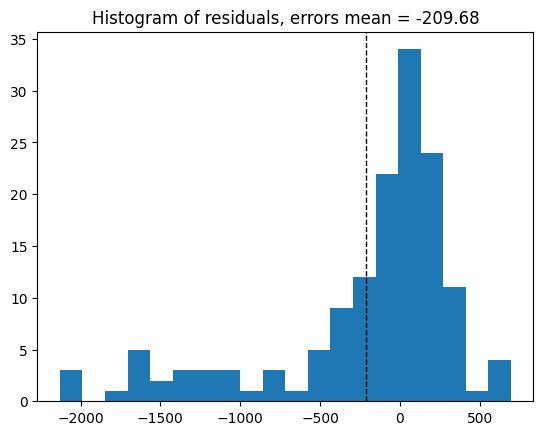

In [70]:
plt.hist(errors, bins = 20)
plt.axvline(errors.mean(), color='k', linestyle='dashed', linewidth=1)
plt.title(f'Histogram of residuals, errors mean = {np.round(errors.mean(), 2)}')
plt.show()

# Regresja wielomianowa

Nie zawsze jednak zależność jest liniowa. Wraz ze wzrostem temperatury z 15°C na 25°C liczba rowerzystów będzie większa, jednak w przypadku wzrostu z 25°C na 35°C zależność może być odwrotna, nie mówiąc o jeszcze wyższych temperaturach. Korzystamy z wielomianu n-tego stopnia, czyli tworzymy nowe cechy, które są potęgą od 1 do n-tego stopnia. Następnie tworzymy regresję liniową wielu zmiennych, które stworzono na podstawie jednej – wielomian to nic innego niż inżynieria cech (Feature engineering)!

Stwórzmy regresję wielomianową w oparciu o temperaturę dla stopnia 1, 2, 3, 5, 10 oraz 20. Skorzystamy z klasy PolynomialFeatures z biblioteki sklearn, która generuje nową macierz cech składającą się ze wszystkich kombinacji cech o stopniu mniejszym lub równym podanemu stopniowi. Na ten moment korzystajmy z jednej cechy, ale jeśli nasz zbiór X miałby 2 cechy i jej postać to [a, b] to wielomian drugiego stopnia to cechy [1, a, b, a^2, ab, b^2], 1 – to wyraz wolny.


Dla każdego wielomianu wyliczymy R2 oraz RMSE dla zbioru treningowego oraz RMSE dla zbioru testowego.

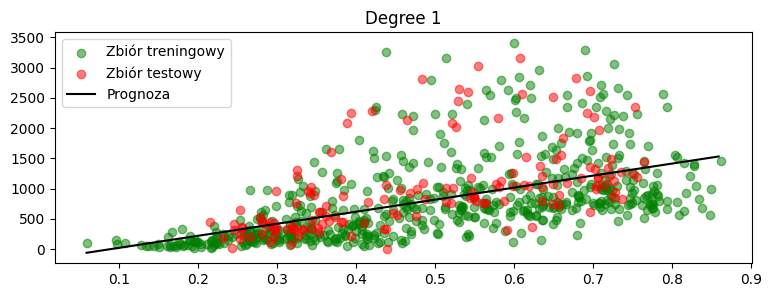

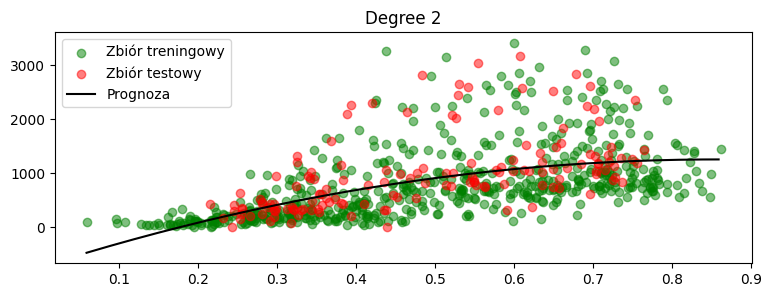

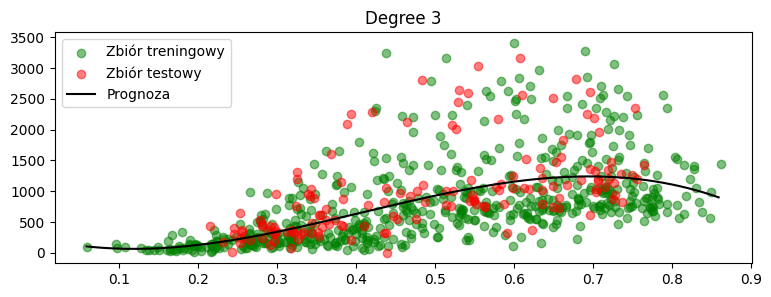

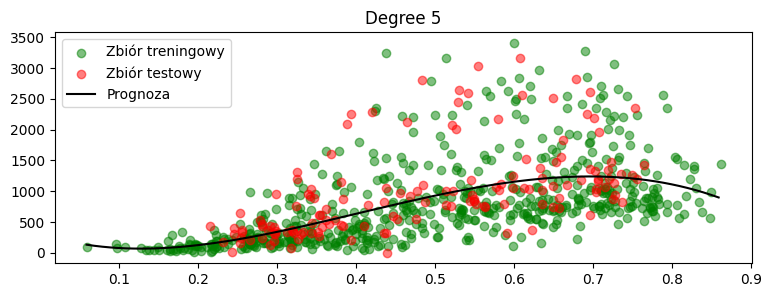

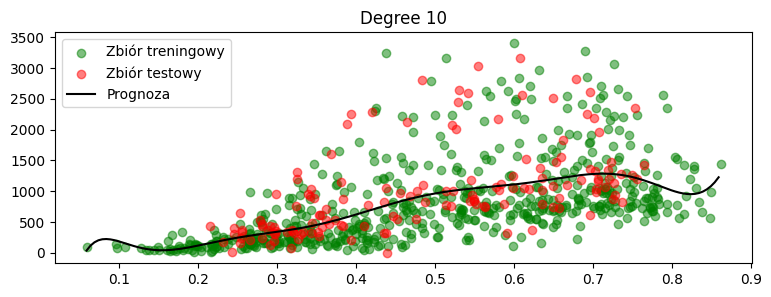

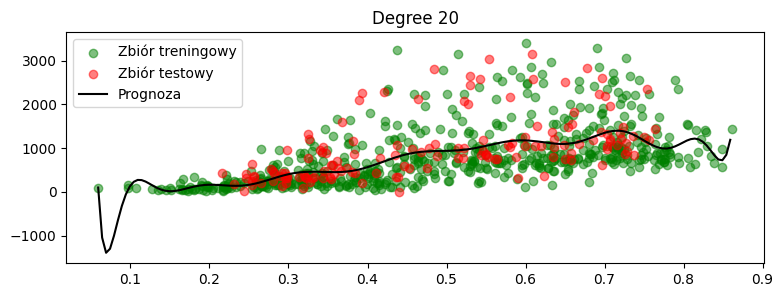

In [72]:
from sklearn.preprocessing import PolynomialFeatures

# Tworzymy puste listy do przechowywania metryk oceny modeli
r_2_train_list = []
rmse_train_list = []
rmse_test_list = []

# Generujemy gęstą siatkę punktów X do wizualizacji krzywej regresji
X_linespace = pd.DataFrame(
    np.arange(X.min().iloc[0], X.max().iloc[0], step=0.005),
    columns=X_train.columns
)

# Testujemy modele o różnych stopniach wielomianu
for degree in [1, 2, 3, 5, 10, 20]:

    # Tworzymy transformator wielomianowy
    poly_transformer = PolynomialFeatures(degree=degree)

    # Transformacja danych treningowych
    X_train_transformed = poly_transformer.fit_transform(X_train)

    # Tworzymy i uczymy model
    polynomial_regression = LinearRegression()
    polynomial_regression.fit(X_train_transformed, y_train)

    # Tworzymy wykres
    plt.figure(figsize=(9, 3))

    # Punkty treningowe
    plt.scatter(
        X_train.iloc[:, 0],
        y_train,
        color='green',
        alpha=0.5,
        label='Zbiór treningowy'
    )

    # Punkty testowe
    plt.scatter(
        X_test.iloc[:, 0],
        y_test,
        color='red',
        alpha=0.5,
        label='Zbiór testowy'
    )

    # Predykcja dla wizualizacji wielomianu
    y_fitted = polynomial_regression.predict(
        poly_transformer.transform(X_linespace)
    )

    # Krzywa regresji
    plt.plot(
        X_linespace.iloc[:, 0],
        y_fitted,
        color='black',
        label='Prognoza'
    )

    plt.title(f'Degree {degree}')
    plt.legend(loc='upper left')
    plt.show()

    # Predykcja na zbiorze treningowym
    prediction_train = polynomial_regression.predict(X_train_transformed)

    # Transformacja i predykcja na zbiorze testowym
    X_test_transformed = poly_transformer.transform(X_test)
    prediction_test = polynomial_regression.predict(X_test_transformed)

    # Ocena modelu
    r_2_train_list.append(
        r2_score(y_train, prediction_train)
    )

    rmse_train_list.append(
        sqrt(mean_squared_error(y_train, prediction_train))
    )

    rmse_test_list.append(
        sqrt(mean_squared_error(y_test, prediction_test))
    )

Trzeci stopień wielomianu wydaje się zgodny z tym, o czym wcześniej mówiliśmy. Patrząc na kolejne wykresy widać, że model uczy się szumu, przeucza się, a tym samym nie potrafi generalizować. Sprawdźmy metryki dla zbioru treningowego oraz testowego w zależności od stopnia wielomianu.

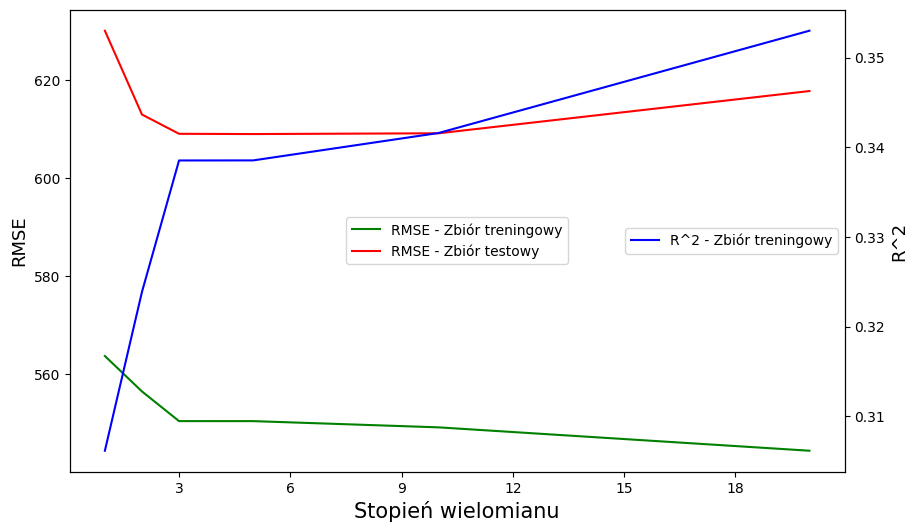

In [73]:
from matplotlib.ticker import MaxNLocator
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot()
ax.plot([1, 2, 3, 5, 10, 20], rmse_train_list, color='green', label='RMSE - Zbiór treningowy')
ax.plot([1, 2, 3, 5, 10, 20], rmse_test_list, color='red', label='RMSE - Zbiór testowy')
ax.legend(loc='center')
ax.xaxis.set_major_locator(MaxNLocator(integer=True)) # Ustawienie typu int dla wartości z osi X
ax.set_ylabel('RMSE', size=13)
ax.set_xlabel('Stopień wielomianu', size=15)

# Dodanie drugiej osi y dla R^2
ax2=ax.twinx()
ax2.plot([1, 2, 3, 5, 10, 20], r_2_train_list, color='blue', label='R^2 - Zbiór treningowy')
ax2.legend(loc='center right')
ax2.set_ylabel('R^2', size=13)

plt.show()

Wraz ze wzrostem stopnia wielomianu minimalizują się metryki dla zbioru treningowego oraz testowego, jednak do pewnego momentu, od którego wyniki dla zbioru testowego są coraz gorsze. Od tego momentu model uczy się szumu ze zbioru treningowego. Spotykamy tutaj pojęcie Bias–variance tradeoff, czyli kompromis pomiędzy obciążeniem a wariancją.

-Bias – model średnio prognozuje nieprawdziwą wartość.
-Variance – jeśli dla podobnych wartości cech model prognozuje podobną wartość, to wariancja jest mała. Jeśli natomiast niewielka zmiana cechy bardzo wpływa na prognozę, to wariancja jest wysoka.

Chcemy aby model potrafił generalizować, czyli wytrenowany model na zbiorze treningowym potrafi poprawnie prognozować wartości ze zbioru testowego, których wcześniej nie widział. Aby tak było, nie może dojść do niedotrenowania (underfitting) lub przetrenowania (overfitting).

Niedotrenowanie – model jest zbyt prosty, nie znajduje zależności i nie zwraca dobrych wyników nawet dla zbioru treningowego.
Przetrenowanie – model nauczył się szumu, nie potrafi generalizować, nauczył się wartości dla poszczególnych obserwacji.

# Zbiór walidacyjny – sprawdzian krzyżowy

Wybierzmy zatem ten stopień wielomianu, dla którego najlepsze wyniki mamy w zbiorze testowym. Tak może się wydawać, jednak to częsty błąd! Jest to wyciek danych, czyli data leakage. Ma miejsce, gdy model ma dostęp do informacji, która w praktyce nie byłaby dostępna. To jest tak, jakbyśmy chcieli wybrać stopień wielomianu dla danych, których nie znamy. Nie da się. Stopień wielomianu to hiperparametr modelu, czyli parametr podawany przez programistę. Musimy zatem wybrać taki hiperparametr, który da najlepszy wynik dla zbioru testowego, nie znając tego zbioru! Stosujemy do tego zbioru walidację, a dokładniej k-krotną walidację krzyżową.


Dzielimy nasz zbiór treningowy na k podzbiorów. W każdej iteracji jeden podzbiór jest walidacyjnym, a pozostałe podzbiorem treningowym. Uczymy modele na podzbiorach treningowych i liczymy metryki dla walidacyjnego. Wybieramy hiperparametr, który daje najlepszą średnią z podzbiorów walidacyjnych. Zauważ, każdy podzbiór raz jest walidacyjnym, a w pozostałych przypadkach należy do podzbioru treningowego.

Do podziału zbioru treningowego na podzbiory walidacyjne wykorzystamy klasę KFold, w której podajemy na ile podzbiorów chcemy podzielić nasz zbiór treningowy.

In [74]:
from sklearn.model_selection import KFold
cv = KFold(n_splits=5, shuffle=False)


# Wybór hiperparametrów

Wybierzemy klasę Grid Search (siatka hiperparametrów). Należy sprawdzić wszystkie kombinacje przekazanych hiperparametrów i wybrać te, które dają najlepszy średni wynik ze zbiorów walidacyjnych – wykorzystasz poznaną walidację krzyżową.

Nasz model musi najpierw przekształcić dane (stopień wielomianu), a następnie na nich wytrenować model, stąd też kolejność działań jest istotna - stworzymy nasz pierwszy Pipeline, który uwzględnia różne operacje. Wkrótce powiemy o tym więcej.

In [76]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

# Tworzymy Pipeline (potok przetwarzania danych)
# Krok 1: PolynomialFeatures - generuje cechy wielomianowe
# Krok 2: LinearRegression - uczy model regresji liniowej na nowych cechach
polynomial_regression_pipeline = make_pipeline(
    PolynomialFeatures(),
    LinearRegression()
)

# Definiujemy siatkę hiperparametrów do przetestowania
# GridSearchCV sprawdzi modele dla wielomianów stopnia:
# 1, 2, 3, 4 oraz 5
params = {
    'polynomialfeatures__degree': [1, 2, 3, 4, 5]
}

# Tworzymy obiekt GridSearchCV
polynomial_regression_gridsearch = GridSearchCV(
    estimator=polynomial_regression_pipeline,  # model do optymalizacji
    param_grid=params,                         # lista parametrów do sprawdzenia
    scoring='neg_mean_squared_error',          # kryterium oceny modelu
                                                # (im mniejszy błąd MSE, tym lepiej)
    cv=cv                                      # liczba foldów walidacji krzyżowej
)

# Uruchamiamy proces wyszukiwania najlepszych parametrów
#
# Dla każdego stopnia wielomianu:
# 1. Tworzony jest wielomian
# 2. Trenowany jest model regresji
# 3. Wykonywana jest walidacja krzyżowa
# 4. Obliczany jest średni błąd MSE
#
# Na końcu wybierany jest model z najniższym błędem.
polynomial_regression_gridsearch.fit(X_train, y_train)

# Wyświetlenie najlepszego zestawu parametrów
print(
    "\nNajlepsze hiperparametry:",
    polynomial_regression_gridsearch.best_params_,
    "\n"
)

# Pobranie najlepszego modelu znalezionego przez Grid Search
polynomial_regression_model = (
    polynomial_regression_gridsearch.best_estimator_
)

# Predykcja na zbiorze testowym
predictions = polynomial_regression_model.predict(X_test)

# Obliczenie błędu RMSE na zbiorze testowym
print(
    f'RMSE: {np.sqrt(mean_squared_error(y_test, predictions))}'
)


Najlepsze hiperparametry: {'polynomialfeatures__degree': 3} 

RMSE: 609.076780249834


Najlepsze wyniki dla zbiorów walidacyjnych uzyskaliśmy dla wielomianu stopnia 3. Porównaj wynik z poprzednim modelem! Tak, zgadza się – poprawiliśmy wynik.

# Regresja wielu zmiennych

In [77]:
# Podział na zmienne objaśniające i zmienną objaśnianą
X = bike_data[numeric_features].copy()
y = bike_data[target].copy()

# Podział na zbiór treningowy i testowy (taki sam podział co poprzednio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Uczymy model
polynomial_regression_pipeline = make_pipeline(PolynomialFeatures(),
                                               LinearRegression())
params = {'polynomialfeatures__degree': [1, 2, 3, 4, 5]}
polynomial_regression_gridsearch = GridSearchCV(polynomial_regression_pipeline,
                                                params,
                                                scoring='neg_mean_squared_error', # wybrane będą takie hiperparametry które dadzą najmniejszą wartość dla tego scoringu
                                                cv=cv)

polynomial_regression_gridsearch.fit(X_train, y_train)
print("\nNajlepsze hiperparametry:", polynomial_regression_gridsearch.best_params_, "\n")

polynomial_regression_model = polynomial_regression_gridsearch.best_estimator_
predictions = polynomial_regression_model.predict(X_test)
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, predictions))}')



Najlepsze hiperparametry: {'polynomialfeatures__degree': 1} 

RMSE: 618.1519697010564


Ups… Wyniki na zbiorze testowym są gorsze. Co jest nie tak, przecież daliśmy modelowi więcej zmiennych? Czemu tylko 1 stopień wielomianu?

Wykorzystując wielomian dla wielu zmiennych tworzymy kolejne, często takie, które nic nie wnoszą oraz napotykamy na problem klątwy wielowymiarowości. Powinniśmy zatem zrobić selekcję cech i nie brać wszystkich stworzonych.

# Regularyzacja

Ogólna idea wprowadzenia regularyzacji jest następująca: im więcej stopni swobody, czyli im więcej różnych wag ma dany model, tym prościej ulega on zjawisku overfittingu. Każda waga odpowiada jednej cesze (feature) danych wejściowych. Czyli zmniejszając ilość wag o dużych wartościach, zapobiegamy zjawisku overfittingu.

Lasso

# LASSO

Lasso to regresja liniowa z tzw. regularyzacją L1. Sprawia to, że mniej znaczace cechy mają wewnętrzne wagi zmniejszone do zera, czyli W OGÓLE nie wpływają one na decyzyjność modelu ( np. czy ktoś posiada w domu kota, nie ma zazwyczaj większego znaczenia przy ustalaniu pochodzenia danej osoby na bazie powyższych cech).

Najważniejszy parametr: alpha - określa stopień regularyzacji: im większa, tym bardziej zmniejszane są mniej znaczące cechy. 0.0 - brak regularyzacji, zachowuje się jak LinearRegression.

# Ridge


Ridge – regresja liniowa z tzw. regularyzacją L2. Powoduje ona, podobnie jak Lasso, iż mniej znaczące cechy ulegają pomniejszeniu, lecz nie do zera, ale do wartości bliskiej zeru, czyli cecha ta posiada MINIMUM.

W tym wypadku cecha, czy ktoś posiada w domu kota, ma minimalny wpływ na predykcję naszego modelu.

Najważniejszy parametr: alpha – określa stopień regularyzacji, im większa, tym bardziej zmniejszane są mniej znaczące cechy. 0.0 – brak regularyzacji, zachowuje się jak LinearRegression.

# ElasticNet

Najważniejsze parametry:

alpha – określa stopień regularyzacji, im większa, tym bardziej zmniejszane są mniej znaczące cechy. 0.0 - brak regularyzacji, zachowuje się jak LinearRegression.
l1_ratio – określa stopień, jak bardzo klasyfikator zachowuje się jak Lasso. Wartość 1.0 -> mamy Lasso, wartość 0.0 -> mamy Ridge.
Zaletą jest fakt, że za pomocą Lasso możemy wyznaczyć najważniejsze cechy modelu.

# PODSUMOWANIE
- Używamy Ridge, jeśli chcemy zmniejszyć ilość cech modelu.
-Używamy Lasso albo ElasticNet, jeśli podejrzewamy, że tylko kilka cech jest przydatnych.
-Preferujemy ElasticNet nad Lasso, gdyż Lasso jest wrażliwe na korelację między cechami oraz na dużą ilość cech.
-Nie używamy LinearRegression, gdyż jest "do bani" :)

In [84]:
# Importujemy model Elastic Net
# Elastic Net łączy regularyzację Lasso (L1) oraz Ridge (L2)
from sklearn.linear_model import ElasticNet

# Tworzymy Pipeline:
# 1. PolynomialFeatures - generuje cechy wielomianowe
# 2. ElasticNet - uczy model regresji z regularyzacją
polynomial_regression_pipeline = make_pipeline(
    PolynomialFeatures(),
    ElasticNet()
)

# Definiujemy siatkę hiperparametrów do przetestowania
params = {
    # Stopień wielomianu
    'polynomialfeatures__degree': [1, 2, 3, 4, 5],

    # Siła regularyzacji
    # Im większa wartość alpha, tym mocniej karane są duże współczynniki
    'elasticnet__alpha': [
        1e-5, 1e-4, 1e-3,
        1e-2, 1e-1,
        0.0, 1.0, 10.0, 100.0
    ],

    # Proporcja między regularyzacją L1 i L2
    # 0.0 = czysty Ridge
    # 1.0 = czysty Lasso
    # wartości pośrednie = Elastic Net
    'elasticnet__l1_ratio': np.arange(0, 1.1, 0.1)
}

# Tworzymy Grid Search
polynomial_regression_gridsearch = GridSearchCV(
    estimator=polynomial_regression_pipeline,
    param_grid=params,
    scoring='neg_mean_squared_error',
    cv=cv
)

# Uruchamiamy wyszukiwanie najlepszych parametrów
polynomial_regression_gridsearch.fit(X_train, y_train)

# Wyświetlamy najlepszą kombinację parametrów
print(
    "\nNajlepsze hiperparametry:",
    polynomial_regression_gridsearch.best_params_,
    "\n"
)

# Pobieramy najlepszy model znaleziony przez Grid Search
polynomial_regression_model = (
    polynomial_regression_gridsearch.best_estimator_
)

# Wykonujemy predykcję na zbiorze testowym
predictions = polynomial_regression_model.predict(X_test)

# Obliczamy błąd RMSE
print(
    f'RMSE: {np.sqrt(mean_squared_error(y_test, predictions))}'
)

C:\Users\micha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.181e+07, tolerance: 2.207e+04
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\Users\micha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.663e+07, tolerance: 2.268e+04
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of th


Najlepsze hiperparametry: {'elasticnet__alpha': 1.0, 'elasticnet__l1_ratio': 1.0, 'polynomialfeatures__degree': 5} 

RMSE: 584.8854667922697


# Wykorzystanie zmiennych kategorycznych

Zostały nam jeszcze zmienne kategoryczne. Dla nich nie powinniśmy tworzyć wielomianu tylko ONE HOT ENCODER, dlatego zrobimy w Pipeline rozróżnienie dla zmiennych numerycznych i kategorycznych. Ponadto zlogarytmujmy zmienne numeryczne. Jeśli cofniesz się do części o eksploracji danych, to zobaczysz, że rozkłady są skośne ????

In [85]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler

# =========================
# Przygotowanie danych
# =========================

# Tworzymy macierz cech X:
# - zmienne numeryczne
# - zmienne kategoryczne
X = bike_data[numeric_features + categorical_features].copy()

# Tworzymy zmienną objaśnianą (target)
y = bike_data[target].copy()

# Dzielimy dane na zbiór treningowy i testowy
# shuffle=False zachowuje kolejność obserwacji
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

# =========================
# Pipeline dla zmiennych numerycznych
# =========================

numeric_transformer = Pipeline(steps=[

    # Transformacja potęgowa (Yeo-Johnson)
    # Zmniejsza skośność rozkładu zmiennych
    ('logtransformer', PowerTransformer()),

    # Standaryzacja danych:
    # średnia = 0
    # odchylenie standardowe = 1
    ('standardscaler', StandardScaler()),

    # Tworzenie cech wielomianowych
    # Stopień wielomianu będzie wybierany przez GridSearchCV
    ('polynomialfeatures', PolynomialFeatures())
])

# =========================
# Pipeline dla zmiennych kategorycznych
# =========================

categorical_transformer = Pipeline(steps=[

    # Kodowanie One-Hot Encoding
    # Zamienia kategorie na zmienne binarne 0/1
    #
    # handle_unknown='ignore'
    # pozwala obsłużyć nowe kategorie,
    # które nie wystąpiły podczas trenowania
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# =========================
# Połączenie obu pipeline'ów
# =========================

preprocessor = ColumnTransformer(
    transformers=[

        # Transformacje dla kolumn numerycznych
        ('num', numeric_transformer, numeric_features),

        # Transformacje dla kolumn kategorycznych
        ('cat', categorical_transformer, categorical_features)
    ]
)

# =========================
# Końcowy Pipeline
# =========================

# Krok 1:
# przygotowanie danych

# Krok 2:
# trenowanie modelu Elastic Net

final_pipeline = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('regressor', ElasticNet())
])

# =========================
# Siatka hiperparametrów
# =========================

params = {

    # Stopień wielomianu dla zmiennych numerycznych
    'preprocessor__num__polynomialfeatures__degree':
        [1, 2, 3, 4, 5],

    # Siła regularyzacji
    'regressor__alpha':
        [1e-5, 1e-4, 1e-3, 1e-2,
         1e-1, 0.0, 1.0, 10.0, 100.0],

    # Proporcja między Lasso i Ridge
    #
    # 0.0 -> Ridge
    # 1.0 -> Lasso
    # wartości pośrednie -> Elastic Net
    'regressor__l1_ratio':
        np.arange(0, 1.1, 0.1)
}

# =========================
# Grid Search
# =========================

# GridSearchCV:
# - sprawdzi wszystkie kombinacje parametrów
# - wykona walidację krzyżową
# - wybierze model z najmniejszym błędem MSE

final_polynomial_regression_gridsearch = GridSearchCV(
    estimator=final_pipeline,
    param_grid=params,

    # Im mniejszy MSE tym lepiej
    scoring='neg_mean_squared_error',

    # Liczba foldów walidacji krzyżowej
    cv=cv
)

# =========================
# Trenowanie modeli
# =========================

# Dla każdej kombinacji parametrów:
# 1. przygotowanie danych
# 2. kodowanie kategorii
# 3. standaryzacja
# 4. tworzenie wielomianów
# 5. trenowanie Elastic Net
# 6. walidacja krzyżowa

final_polynomial_regression_gridsearch.fit(
    X_train,
    y_train
)

# Wyświetlenie najlepszych parametrów
print(
    "\nNajlepsze hiperparametry:",
    final_polynomial_regression_gridsearch.best_params_,
    "\n"
)

# =========================
# Najlepszy model
# =========================

# Pobieramy model o najlepszych parametrach
final_polynomial_regression_model = (
    final_polynomial_regression_gridsearch.best_estimator_
)

# =========================
# Predykcja
# =========================

# Prognoza dla zbioru testowego
predictions = final_polynomial_regression_model.predict(X_test)

# =========================
# Ocena modelu
# =========================

# RMSE (Root Mean Squared Error)
# Informuje o przeciętnym błędzie predykcji
print(
    f'RMSE: {np.sqrt(mean_squared_error(y_test, predictions))}'
)

C:\Users\micha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.169e+07, tolerance: 2.207e+04
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\Users\micha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.884e+07, tolerance: 2.268e+04
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of th


Najlepsze hiperparametry: {'preprocessor__num__polynomialfeatures__degree': 1, 'regressor__alpha': 0.1, 'regressor__l1_ratio': 0.4} 

RMSE: 483.937941929758


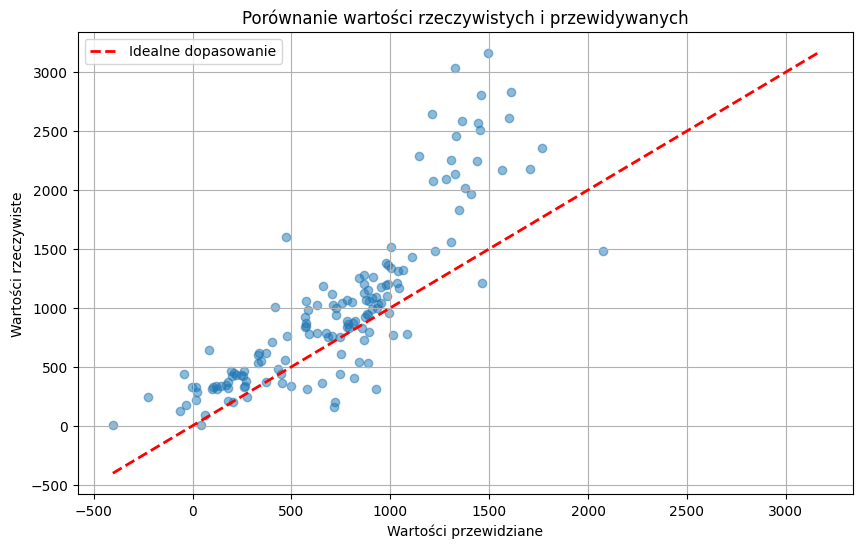

In [87]:
# Predykcja dla zbioru testowego
predictions = final_polynomial_regression_model.predict(X_test)

# Utworzenie wykresu
plt.figure(figsize=(10, 6))

# Wykres punktowy:
# oś X - wartości przewidziane przez model
# oś Y - wartości rzeczywiste
plt.scatter(
    predictions,
    y_test,
    alpha=0.5
)

# Wyznaczenie zakresu osi
min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())

# Linia idealnego dopasowania (y = x)
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label='Idealne dopasowanie'
)

# Opisy osi
plt.xlabel('Wartości przewidziane')
plt.ylabel('Wartości rzeczywiste')

# Tytuł wykresu
plt.title('Porównanie wartości rzeczywistych i przewidywanych')

# Legenda
plt.legend()

# Siatka pomocnicza
plt.grid(True)

# Wyświetlenie wykresu
plt.show()

# ZADANIE

In [89]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# =========================
# Predykcja modelu
# =========================
# Generujemy prognozy dla zbioru testowego
predictions = final_polynomial_regression_model.predict(X_test)

# =========================
# Obliczanie metryk
# =========================

# R² - jak dobrze model wyjaśnia zmienność danych (1.0 = idealny model,0.0 = model losowy)
r2 = r2_score(y_test, predictions)

# MAE - średni błąd bezwzględny -mówi o średnim odchyleniu predykcji od wartości rzeczywistej
mae = mean_absolute_error(y_test, predictions)

# MSE - średni błąd kwadratowy - bardziej karze duże błędy
mse = mean_squared_error(y_test, predictions)

# RMSE - pierwiastek z MSE (interpretowalny w jednostkach danych)
rmse = np.sqrt(mse)


print(f'R²   = {r2:.4f}')
print(f'MAE  = {mae:.4f}')
print(f'MSE  = {mse:.4f}')
print(f'RMSE = {rmse:.4f}')

R²   = 0.5247
MAE  = 348.5852
MSE  = 234195.9316
RMSE = 483.9379


In [91]:
# Wizualna ocena modelu (Rzeczywiste vs Predykcje)

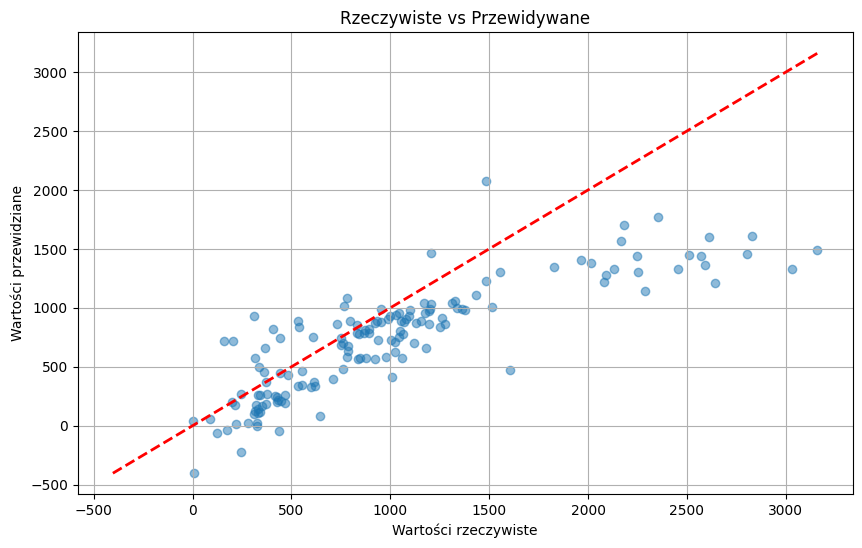

In [92]:
import matplotlib.pyplot as plt


# Wykres: rzeczywiste vs przewidywane

plt.figure(figsize=(10,6))

# Oś X - wartości rzeczywiste
# Oś Y - wartości przewidziane przez model
plt.scatter(
    y_test,
    predictions,
    alpha=0.5
)

# Linia idealnego dopasowania (y = x) Punkty na tej linii oznaczają perfekcyjne predykcje
min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2
)

plt.xlabel('Wartości rzeczywiste')
plt.ylabel('Wartości przewidziane')

plt.title('Rzeczywiste vs Przewidywane')

plt.grid(True)

plt.show()

In [93]:
# Analiza reszt

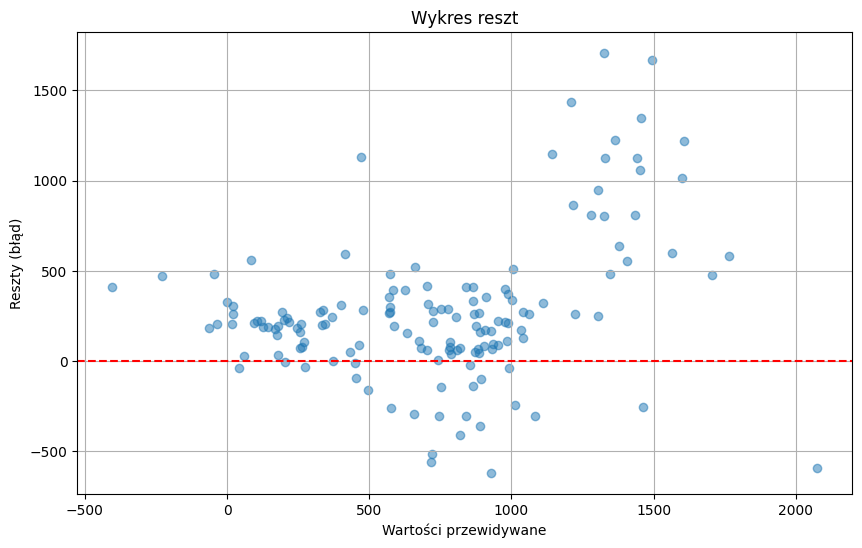

In [94]:
# reszty = błąd modelu (różnica rzeczywista - predykcja)
residuals = y_test - predictions


# wykres reszt
plt.figure(figsize=(10,6))

plt.scatter(
    predictions,
    residuals,
    alpha=0.5
)

# Linia zerowa (idealny brak błędu)
plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel('Wartości przewidywane')
plt.ylabel('Reszty (błąd)')
plt.title('Wykres reszt')

plt.grid(True)
plt.show()

In [95]:
# histogram bledow

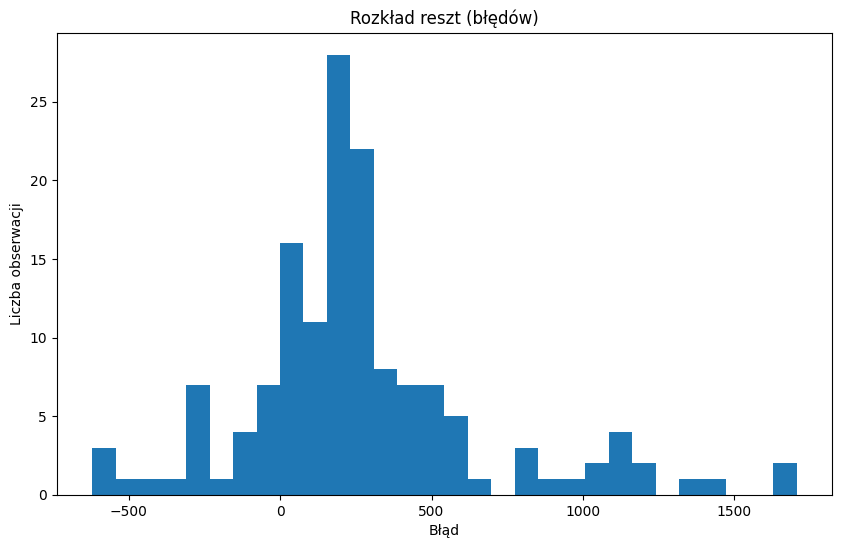

In [96]:

plt.figure(figsize=(10,6))

plt.hist(
    residuals,
    bins=30
)

plt.title('Rozkład reszt (błędów)')
plt.xlabel('Błąd')
plt.ylabel('Liczba obserwacji')

plt.show()

In [104]:
import pandas as pd

comparison = pd.DataFrame({
    'Metryka': ['R²', 'MAE', 'MSE', 'RMSE'],


    'Model końcowy': [
        r2,
        mae,
        mse,
        rmse
    ]
})

# Wyświetlenie tabeli porównawczej
print(comparison)

  Metryka  Model końcowy
0      R²       0.524682
1     MAE     348.585194
2     MSE  234195.931639
3    RMSE     483.937942


# WNIOSKI

Model drugi osiągnął lepsze wyniki niż model pierwszy we wszystkich kluczowych metrykach.

Wartość R² wzrosła z 0.306 do 0.525, co oznacza, że model wyjaśnia znacznie większą część zmienności danych.

RMSE spadło z 630 do 484, co wskazuje na zmniejszenie średniego błędu predykcji.

Również MSE uległo znacznemu zmniejszeniu, co potwierdza lepszą jakość dopasowania modelu.

Na tej podstawie można stwierdzić, że model drugi jest zdecydowanie bardziej skuteczny i lepiej nadaje się do predykcji danych.

Poprawa jakości modelu wynika z zastosowania bardziej złożonej transformacji danych oraz regularyzacji, co pozwoliło lepiej uchwycić nieliniowe zależności w danych.